## Section 1 - Environment Setup and Dependency Installation

In [ ]:
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4

## Section 2 — Library Imports, Experimental Reproducibility, and Configuration


In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth import UnslothTrainer, UnslothTrainingArguments
from unsloth.chat_templates import train_on_responses_only

import os
import re
import gc
import json
import random
import warnings

from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from google.colab import drive
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import EarlyStoppingCallback, TrainerCallback

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
drive.mount("/content/drive")

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

Mounted at /content/drive


### Reproducibility Seed Setting

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Main Folder & Path Setting

In [ ]:
# Menyimpan ID model Qwen2.5-Math-1.5B-Instruct dari Hugging Face Hub.
MODEL_MATH = "Qwen/Qwen2.5-Math-1.5B-Instruct"


# Menyimpan path direktori model hasil SLERP merge final dari Kode 03.
SLERP_MERGED_DIR = (
    "/content/drive/MyDrive/Dataset Skripsi/"
    "Result Model Merging Dual Prompt Full Size/final_slerp_mergekit"
)


# Menyimpan path file ringkasan hasil evaluasi model SLERP sebelum tahap
# supervised fine-tuning, yang digunakan sebagai baseline perbandingan.
SLERP_BASELINE_SUMMARY_PATH = (
    "/content/drive/MyDrive/Dataset Skripsi/"
    "Result Model Merging Dual Prompt Full Size/evaluation/final_slerp_summary.csv"
)


# Menyimpan path file dataset supervised fine-tuning versi 4K.
SFT_DATASET_PATH_4K = (
    "/content/drive/MyDrive/Dataset Skripsi/dataset/sft/sft_dataset.json"
)

# Menyimpan path file dataset supervised fine-tuning versi full.
SFT_DATASET_PATH_FULL = (
    "/content/drive/MyDrive/Dataset Skripsi/dataset/sft/sft_qwen_merged_dataset.json"
)


# Menyimpan path file GSM8K test set yang digunakan untuk evaluasi model.
TEST_DATASET_PATH = (
    "/content/drive/MyDrive/Dataset Skripsi/dataset/test/"
    "Full Size Test Set - V3/GSM8K Test Set.json"
)


# Menetapkan direktori root untuk menyimpan seluruh output eksperimen
# supervised fine-tuning.
ROOT_OUTPUT_DIR = "/content/drive/MyDrive/Dataset Skripsi/Supervised Fine Tuning"

# Membentuk path direktori untuk menyimpan hasil evaluasi model.
EVAL_DIR = os.path.join(ROOT_OUTPUT_DIR, "evaluation")

# Membentuk path direktori untuk menyimpan chart hasil eksperimen.
CHARTS_DIR = os.path.join(ROOT_OUTPUT_DIR, "charts")

# Membentuk path direktori untuk menyimpan checkpoint, log, dan artefak
# dari setiap proses training.
RUNS_DIR = os.path.join(ROOT_OUTPUT_DIR, "runs")


# Membentuk path file CSV untuk menyimpan ringkasan perbandingan hasil
# supervised fine-tuning model Math murni dan model hasil SLERP merge.
COMBINED_SFT_SUMMARY_PATH = os.path.join(
    EVAL_DIR,
    "pure_vs_merged_sft_summary.csv",
)


# Membuat seluruh direktori output yang diperlukan jika direktori belum ada.
# exist_ok=True mencegah error ketika notebook dijalankan ulang dan direktori
# tersebut sudah tersedia.
for directory in [ROOT_OUTPUT_DIR, EVAL_DIR, CHARTS_DIR, RUNS_DIR]:
    os.makedirs(directory, exist_ok=True)

### Inference and Chart Static Variables

In [ ]:
STRATA = ["L1", "L2", "L3"]

# Palet warna diseragamkan dengan chart dual-prompt & SLERP (Kode 02/03):
# peach untuk Bahasa Inggris, oranye tua untuk Bahasa Indonesia.
EN_COLOR = "#F5CBA7"
ID_COLOR = "#E67E22"

# Palet tambahan khusus kurva training (train vs eval), tetap satu keluarga
# dengan warna yang sudah dipakai sepanjang hari ini (biru dari chart single-
# prompt, oranye dari chart dual-prompt/SLERP) supaya seluruh rangkaian chart
# skripsi terasa satu sistem visual.
TRAIN_COLOR = "#4A90D9"
EVAL_COLOR = "#E67E22"

MAX_SEQ_LENGTH = 2048  # konsisten di training & inference
LOAD_IN_4BIT = False

GENERATION_CONFIG = {
    "max_new_tokens": 1024,
    "do_sample": False,
    "use_cache": True,
}

# Ukuran sampel untuk tracking akurasi downstream PER EPOCH (bukan full test
# set -- full-set setiap epoch terlalu mahal waktu). Full test set tetap
# dipakai untuk evaluasi AKHIR pasca-training di Section 11-12.
EPOCH_EVAL_SAMPLE_PER_STRATUM = 40  # ~120 soal/bahasa, cepat tapi representatif

sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": "#F8F9FA",
    "figure.facecolor": "#FFFFFF",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Section 3 - Utils & Data Preprocessing

In [ ]:
def normalize_number(text):
    """Menormalisasi string jawaban numerik agar bisa dibandingkan secara exact-match pada GSM8K.

    Fungsi ini membersihkan simbol mata uang, satuan kata dalam Bahasa Indonesia,
    dan tanda baca pemisah ribuan, lalu mengonversi hasilnya menjadi representasi
    desimal ternormalisasi (tanpa trailing zero) agar "10.0" dan "10" dianggap sama.

    Args:
        text: Nilai mentah yang akan dinormalisasi. Bisa berupa str, angka, atau None.

    Returns:
        String angka yang sudah dinormalisasi (misal "10.5"), atau string huruf kecil
        dari teks asli jika teks tidak bisa dikonversi ke angka. Mengembalikan None
        jika input adalah None.
    """
    if text is None:
        return None

    text = str(text).strip()

    text = text.replace("$", "")
    text = text.replace("Rp.", "")
    text = text.replace("Rp", "")
    text = text.replace("\,", "")
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.strip().rstrip(".")

    # Pattern: \b...\b memastikan hanya kata utuh yang cocok, (?i) membuat pencarian
    # tidak case-sensitive, dan grup (orang|buah|...) mendaftar satuan yang akan dihapus.
    text = re.sub(r"(?i)\b(orang|buah|kali|rupiah|unit|hari|jam|menit)\b", "", text)
    text = text.strip()

    # Pattern: -?\d+/\d+ mencocokkan pecahan opsional negatif dengan format "pembilang/penyebut".
    if re.fullmatch(r"-?\d+/\d+", text):
        numerator, denominator = text.split("/")
        if denominator != "0":
            value = Decimal(numerator) / Decimal(denominator)
            return format(value.normalize(), "f")

    try:
        value = Decimal(text)
        return format(value.normalize(), "f")
    except (InvalidOperation, ValueError):
        return text.lower()


def extract_answer(text):
    """Mengekstrak jawaban akhir dari teks keluaran model berdasarkan urutan prioritas pattern.

    Prioritas ekstraksi:
    1. Pola \\boxed{...} (format umum pada output reasoning matematika).
    2. Pola "#### ..." (format marker jawaban khas dataset GSM8K).
    3. Angka terakhir yang muncul di teks sebagai fallback jika kedua pola di atas tidak ditemukan.

    Args:
        text: Teks keluaran model yang akan diekstrak jawabannya. Bisa berupa str atau None.

    Returns:
        Tuple (jawaban, metode) di mana jawaban adalah string hasil ekstraksi (atau None
        jika tidak ditemukan) dan metode adalah salah satu dari "boxed", "gsm8k_marker",
        "last_number_fallback", "missing", atau "not_found".
    """
    if text is None:
        return None, "missing"

    text = str(text).strip()

    patterns = [
        # Pattern: \\boxed\{([^{}]+)\} menangkap isi di dalam \boxed{...},
        # dengan [^{}]+ memastikan tidak melintasi kurung kurawal lain di dalamnya.
        (r"\\boxed\{([^{}]+)\}", "boxed"),
        # Pattern: (?im) mengaktifkan mode multiline + case-insensitive, ^\s*####\s*
        # mencocokkan baris yang diawali tanda "####" (dengan spasi opsional),
        # dan ([^\n]+) menangkap sisa teks di baris tersebut sebagai jawaban.
        (r"(?im)^\s*####\s*([^\n]+)", "gsm8k_marker"),
    ]

    for pattern, method in patterns:
        matches = re.findall(pattern, text)

        # Hanya menerima kecocokan yang tidak kosong dan mengandung setidaknya satu digit,
        # untuk menghindari hasil tangkapan yang berupa teks non-numerik.
        valid_matches = [m.strip() for m in matches if m.strip() and re.search(r"\d", m)]
        if valid_matches:
            return valid_matches[-1], method

    # Pattern: -?\d+(?:[.,]\d+)?(?:/\d+)? mencocokkan angka opsional negatif,
    # dengan bagian desimal opsional (dipisah titik atau koma) dan bagian pecahan opsional.
    numbers = re.findall(r"-?\d+(?:[.,]\d+)?(?:/\d+)?", text)
    if numbers:
        return numbers[-1].strip(), "last_number_fallback"

    return None, "not_found"


def is_correct(raw_output, ground_truth):
    """Mengevaluasi apakah jawaban model benar dengan membandingkan hasil normalisasi.

    Fungsi ini mengekstrak jawaban dari output mentah model, menormalisasi jawaban
    tersebut beserta ground truth, lalu membandingkannya secara exact-match.

    Args:
        raw_output: Teks keluaran mentah dari model yang akan dievaluasi.
        ground_truth: Jawaban benar (referensi) untuk dibandingkan.

    Returns:
        Dictionary berisi prediction (jawaban hasil ekstraksi), normalized_prediction,
        normalized_ground_truth, extraction_method (metode ekstraksi yang berhasil),
        dan correct (boolean status kebenaran jawaban).
    """
    prediction, extraction_method = extract_answer(raw_output)

    normalized_prediction = normalize_number(prediction)
    normalized_ground_truth = normalize_number(ground_truth)

    correct = (
        normalized_prediction is not None
        and normalized_prediction == normalized_ground_truth
    )

    return {
        "prediction": prediction,
        "normalized_prediction": normalized_prediction,
        "normalized_ground_truth": normalized_ground_truth,
        "extraction_method": extraction_method,
        "correct": correct,
    }


def clear_vram(model=None, tokenizer=None):
    """Membersihkan objek model dan tokenizer dari memori serta mengosongkan cache VRAM GPU.

    Fungsi ini berguna untuk mencegah kebocoran memori (memory leak) saat melakukan
    eksperimen berulang dengan banyak model pada satu sesi Google Colab atau notebook.

    Args:
        model: Objek model yang akan dihapus dari memori. Opsional, default None.
        tokenizer: Objek tokenizer yang akan dihapus dari memori. Opsional, default None.

    Returns:
        None.
    """
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer

    # Memaksa garbage collector Python untuk membebaskan objek yang sudah di-delete.
    gc.collect()

    if torch.cuda.is_available():
        # Mengosongkan cache alokasi memori CUDA yang sudah tidak dipakai agar VRAM
        # yang telah dibebaskan benar-benar bisa digunakan kembali oleh proses lain.
        torch.cuda.empty_cache()

## Section 4 - System Prompts

In [ ]:
SYSTEM_PROMPT_EN = r"""
You are a mathematical reasoning assistant.

Solve the problem carefully, step by step.
On the final line, write only the final numerical answer in this format:
\boxed{value}
"""

SYSTEM_PROMPT_ID = r"""
Anda adalah asisten penalaran matematika.

Selesaikan soal dengan cermat secara bertahap.
Pada baris terakhir, tuliskan hanya jawaban numerik akhir dengan format:
\boxed{nilai}
"""

## Section 5 - Dataset Loading & Validation

### Test Set

In [ ]:
# Membuka file test set dan memuat isi JSON ke dalam struktur data Python.
with open(TEST_DATASET_PATH, "r", encoding="utf-8") as f:
    raw_test = json.load(f)


# Mendefinisikan field yang wajib tersedia pada setiap item test set.
required_fields_test = {
    "question",
    "translated_question",
    "answer",
    "stratum",
}


# Memvalidasi setiap item test set untuk memastikan seluruh field wajib tersedia.
# Jika terdapat field yang hilang, error menampilkan indeks item dan nama field
# yang tidak ditemukan.
for idx, item in enumerate(raw_test):
    missing = required_fields_test - set(item.keys())
    if missing:
        raise ValueError(
            f"Data test indeks {idx} tidak memiliki field: {missing}"
        )


# Mengonversi list of dictionary hasil pembacaan JSON menjadi DataFrame pandas.
df_test = pd.DataFrame(raw_test)

# Mengonversi setiap kolom utama menjadi string dan menghapus whitespace pada
# awal maupun akhir teks agar nilai yang digunakan saat inference dan evaluasi
# memiliki format yang konsisten.
df_test["question"] = df_test["question"].astype(str).str.strip()
df_test["translated_question"] = (
    df_test["translated_question"].astype(str).str.strip()
)
df_test["answer"] = df_test["answer"].astype(str).str.strip()
df_test["stratum"] = df_test["stratum"].astype(str).str.strip()


# Memastikan semua label stratum pada test set termasuk dalam daftar STRATA.
# Error ditampilkan apabila ditemukan label stratum di luar daftar tersebut.
if not set(df_test["stratum"].unique()).issubset(set(STRATA)):
    raise ValueError(
        f"Strata tidak valid: {sorted(df_test['stratum'].unique())}"
    )


# Mengekstrak pertanyaan Bahasa Inggris menjadi list untuk inference.
full_q_en = df_test["question"].tolist()

# Mengekstrak pertanyaan Bahasa Indonesia hasil terjemahan menjadi list
# untuk inference.
full_q_id = df_test["translated_question"].tolist()

# Mengekstrak jawaban referensi menjadi list untuk proses evaluasi.
full_answers = df_test["answer"].tolist()

# Mengekstrak label stratum menjadi list untuk menghitung akurasi per stratum.
full_strata = df_test["stratum"].tolist()

### SFT Dataset All Dataset

In [ ]:
def load_sft_dataset(path, cot_source="solution"):
    """Memuat dan menyiapkan dataset supervised fine-tuning dalam bentuk DataFrame.

    Fungsi ini membaca file JSON dataset SFT, mengambil solusi chain-of-thought
    dari field yang dipilih melalui cot_source, memastikan setiap solusi memiliki
    jawaban akhir dalam format \boxed{...}, lalu menyusunnya menjadi DataFrame
    yang siap digunakan pada proses supervised fine-tuning.

    Args:
        path: Path file JSON dataset supervised fine-tuning.
        cot_source: Nama field solusi yang digunakan sebagai sumber chain-of-thought.
            Nilai yang didukung adalah "solution" dan "original_solution".
            Default "solution".

    Returns:
        DataFrame dengan kolom "question", "answer", "solution_distilled",
        dan "stratum". Kolom "question_en" juga ditambahkan jika field
        "question" tersedia pada item dataset.

    Raises:
        ValueError: Jika cot_source bukan "solution" atau "original_solution".
    """
    # Membuka file dataset SFT dan memuat isi JSON ke struktur data Python.
    with open(path, "r", encoding="utf-8") as f:
        raw_sft = json.load(f)

    # Menentukan cara iterasi berdasarkan struktur JSON: .items() untuk
    # dictionary dan enumerate() untuk list.
    sft_records = (
        raw_sft.items()
        if isinstance(raw_sft, dict)
        else enumerate(raw_sft)
    )

    sft_list = []

    # Memproses setiap item dataset menjadi format record yang seragam.
    for key, item in sft_records:
        # Mengambil jawaban referensi dan pertanyaan Bahasa Indonesia, lalu
        # menghapus whitespace pada awal dan akhir teks.
        ans = str(item["answer"]).strip()
        question_id = str(item["translated_question"]).strip()

        # Menggunakan field "solution" sebagai sumber chain-of-thought.
        if cot_source == "solution":
            solution = str(item["solution"]).strip()

            # Menambahkan jawaban akhir dalam format \boxed{} apabila solusi
            # belum memiliki penanda \boxed{.
            if r"\boxed{" not in solution:
                solution = f"{solution}\n\n\\boxed{{{ans}}}"

        # Menggunakan field "original_solution" sebagai sumber chain-of-thought.
        elif cot_source == "original_solution":
            solution = str(item["original_solution"]).strip()

            # Menghapus bagian jawaban berformat GSM8K setelah marker "####"
            # sebelum menambahkan jawaban akhir dalam format \boxed{}.
            if r"\boxed{" not in solution:
                solution = solution.split("####")[0].strip()
                solution = f"{solution}\n\n\\boxed{{{ans}}}"

        # Menghentikan proses jika sumber chain-of-thought tidak dikenali.
        else:
            raise ValueError(f"cot_source tidak dikenal: {cot_source}")

        # Menyusun record SFT dengan pertanyaan Bahasa Indonesia, jawaban
        # referensi, solusi chain-of-thought, dan label stratum.
        entry = {
            "question": question_id,
            "answer": ans,
            "solution_distilled": solution,
            "stratum": item.get("stratum"),
        }

        # Menambahkan pertanyaan versi Bahasa Inggris apabila field "question"
        # tersedia pada item dataset sumber.
        if "question" in item:
            entry["question_en"] = str(item["question"]).strip()

        sft_list.append(entry)

    # Mengonversi seluruh record hasil pemrosesan menjadi DataFrame pandas.
    df_sft = pd.DataFrame(sft_list)

    return df_sft

### Validasi: Filter data train

In [ ]:
def prepare_train_eval_split(df_sft, df_test, seed=SEED, test_size=0.1):
    """Memvalidasi leakage lalu membagi data SFT menjadi train dan eval set.

    Fungsi ini terlebih dahulu memeriksa apakah pertanyaan pada data SFT
    bertumpang tindih dengan kolom ``translated_question`` pada test set utama.
    Jika ada overlap, proses dihentikan untuk mencegah data leakage. Jika tidak
    ada leakage, data SFT dikonversi ke Hugging Face Dataset dan dibagi secara
    acak menjadi train dan evaluation set.

    Args:
        df_sft: DataFrame dataset supervised fine-tuning. Wajib memiliki kolom
            ``question``.
        df_test: DataFrame test set utama. Wajib memiliki kolom
            ``translated_question``.
        seed: Seed random untuk memastikan hasil split dapat direproduksi.
            Default menggunakan konstanta ``SEED``.
        test_size: Proporsi data SFT yang dialokasikan menjadi evaluation set.
            Default ``0.1``, yaitu 10%.

    Returns:
        Tuple berisi:
        - train_dataset: Hugging Face Dataset untuk proses training SFT.
        - eval_dataset: Hugging Face Dataset untuk evaluasi selama training.

    Raises:
        ValueError: Jika ditemukan pertanyaan yang sama antara data SFT dan
            test set utama, yang menandakan potensi data leakage.
    """
    # Membuat himpunan pertanyaan SFT setelah menghapus whitespace di awal/akhir.
    train_question_set = set(df_sft["question"].str.strip())

    # Membuat himpunan pertanyaan test utama dalam Bahasa Indonesia setelah
    # menghapus whitespace di awal/akhir.
    test_question_set_id = set(df_test["translated_question"].str.strip())

    # Mencari pertanyaan yang muncul pada kedua dataset.
    overlap = train_question_set & test_question_set_id

    # Menghentikan proses bila data SFT memuat soal dari test set utama.
    if len(overlap) > 0:
        raise ValueError(
            f"Data leakage terdeteksi: {len(overlap)} soal SFT overlap dengan test set!\n"
            f"Contoh: {list(overlap)[:3]}"
        )

    # Menampilkan status validasi apabila seluruh pertanyaan SFT aman dari leakage.
    print(f"Validasi leakage: OK ({len(df_sft)} soal SFT bersih).")

    # Mengonversi DataFrame pandas ke format Hugging Face Dataset.
    hf_dataset = Dataset.from_pandas(df_sft)

    # Membagi dataset SFT secara acak menjadi train dan eval set menggunakan
    # seed tetap agar pembagian data dapat direproduksi.
    hf_dataset = hf_dataset.train_test_split(test_size=test_size, seed=seed)

    # Mengambil split training untuk fine-tuning model.
    train_dataset = hf_dataset["train"]

    # Mengambil split evaluasi untuk memantau metrik selama training.
    eval_dataset = hf_dataset["test"]

    # Menampilkan jumlah sampel pada setiap split.
    print(f"SFT Train : {len(train_dataset)}")
    print(f"SFT Eval  : {len(eval_dataset)}")

    return train_dataset, eval_dataset

### Train/Eval split untuk monitoring training

In [ ]:
# Memuat dataset SFT dari file JSON dengan field "solution" sebagai sumber
# chain-of-thought, lalu memastikan jawaban akhir memakai format \boxed{}.
df_sft = load_sft_dataset(SFT_DATASET_PATH_4K, cot_source="solution")

# Mengonversi DataFrame pandas ke Hugging Face Dataset agar dapat digunakan
# pada pipeline training dan pemisahan dataset.
hf_dataset = Dataset.from_pandas(df_sft)

# Membagi data SFT secara acak menjadi 90% train dan 10% evaluation set.
# Seed tetap digunakan agar hasil pembagian selalu dapat direproduksi.
hf_dataset = hf_dataset.train_test_split(test_size=0.1, seed=SEED)

# Mengambil split training SFT yang akan dipakai untuk update bobot model.
train_dataset = hf_dataset["train"]

# Mengambil split evaluasi internal SFT untuk evaluasi selama training.
eval_dataset = hf_dataset["test"]

# Menampilkan ukuran setiap subset data yang akan digunakan.
print(f"SFT Train : {len(train_dataset)}")
print(f"SFT Eval  : {len(eval_dataset)}")
print(f"Test EN   : {len(full_q_en)}")
print(f"Test ID   : {len(full_q_id)}")

# Mengubah eval_dataset menjadi DataFrame agar kolomnya mudah diakses
# untuk menyiapkan prompt dan ground-truth tracking per epoch.
df_eval_split = eval_dataset.to_pandas()

# Menyimpan daftar pertanyaan Bahasa Indonesia pada holdout SFT.
# Data ini digunakan untuk mengukur performa per epoch tanpa memakai
# test set utama sebagai data monitoring training.
epoch_val_q_id = df_eval_split["question"].tolist()

# Menyimpan jawaban ground truth dari holdout SFT, sejajar dengan urutan
# pertanyaan pada epoch_val_q_id.
epoch_val_answers = df_eval_split["answer"].tolist()

# Memeriksa apakah dataset SFT menyediakan pertanyaan Bahasa Inggris.
# Variabel boolean ini menentukan apakah evaluasi EN per epoch dapat dijalankan.
EPOCH_TRACK_EN_AVAILABLE = "question_en" in df_eval_split.columns

# Mengambil pertanyaan EN dari holdout SFT bila kolomnya tersedia.
if EPOCH_TRACK_EN_AVAILABLE:
    epoch_val_q_en = df_eval_split["question_en"].tolist()

# Tidak menggantikan pertanyaan EN yang tidak tersedia dengan test set utama,
# agar tracking per epoch tetap bebas dari kebocoran data evaluasi akhir.
else:
    epoch_val_q_en = None
    print(
        "Catatan: kolom 'question_en' tidak tersedia di data SFT -- "
        "tracking EN per-epoch akan di-skip (bukan diganti sampel test set)."
    )

# Menampilkan jumlah contoh holdout SFT yang digunakan untuk tracking
# performa model pada akhir setiap epoch.
print(
    f"Sampel tracking per-epoch (dari eval_dataset SFT): "
    f"{len(epoch_val_q_id)} soal"
)

SFT Train : 3442
SFT Eval  : 383
Test EN   : 1319
Test ID   : 1319
Sampel tracking per-epoch (dari eval_dataset SFT): 383 soal


## Section 6 - Audit Panjang Token

In [ ]:
def audit_completion_length(dataset, tokenizer, column, max_seq_length):
    """Mengaudit distribusi panjang token pada sebuah kolom dataset.

    Fungsi ini menghitung jumlah token untuk setiap teks pada kolom dataset yang
    dipilih, lalu menampilkan statistik panjang token berupa rata-rata, nilai
    maksimum, persentil ke-95, dan jumlah contoh yang mendekati batas panjang
    sekuens. Audit ini berguna untuk mengidentifikasi completion yang berisiko
    dipotong saat proses tokenisasi atau supervised fine-tuning.

    Args:
        dataset: Dataset yang memiliki kolom teks untuk diaudit. Dapat berupa
            Hugging Face Dataset atau struktur lain yang mendukung akses
            ``dataset[column]``.
        tokenizer: Tokenizer model yang memiliki metode ``encode(text)``.
        column: Nama kolom berisi teks yang akan dihitung panjang tokennya,
            misalnya ``"solution_distilled"`` atau ``"question"``.
        max_seq_length: Jumlah token maksimum yang diizinkan dalam satu
            sekuens pada proses training.

    Returns:
        Array NumPy satu dimensi yang memuat panjang token setiap contoh,
        dengan urutan yang sama seperti data pada ``dataset[column]``.

    Raises:
        KeyError: Jika ``column`` tidak tersedia dalam dataset.
        ValueError: Jika kolom yang diaudit kosong, karena statistik seperti
            mean, max, dan percentile tidak dapat dihitung.
    """
    lengths = []

    # Menghitung jumlah token untuk setiap teks dalam kolom yang dipilih.
    for text in dataset[column]:
        lengths.append(len(tokenizer.encode(text)))

    # Mengonversi list Python ke NumPy array agar perhitungan statistik dan
    # operasi vektorisasi dapat dilakukan dengan lebih mudah.
    lengths = np.array(lengths)

    # Menghitung jumlah contoh yang panjangnya telah melewati 90% dari batas
    # sekuens. Contoh ini berisiko terpotong bila prompt, template chat, atau
    # token spesial juga ditambahkan saat training.
    over_limit = (lengths > max_seq_length * 0.9).sum()

    # Menampilkan ringkasan statistik distribusi panjang token.
    print(f"\nAudit panjang token kolom '{column}':")
    print(f"  Rata-rata      : {lengths.mean():.1f} token")
    print(f"  Maksimum       : {lengths.max()} token")
    print(f"  P95            : {np.percentile(lengths, 95):.1f} token")
    print(
        f"  Berisiko terpotong (>{int(max_seq_length * 0.9)} token): "
        f"{over_limit} dari {len(lengths)}"
    )

    return lengths


## Section 7 - Inference & Evaluation Engine

In [ ]:
def run_inference(
    model,
    tokenizer,
    questions,
    system_prompt,
    batch_size=16,
    desc="Inferensi",
):
    """Menjalankan inferensi batch untuk daftar pertanyaan berbasis chat.

    Fungsi ini membangun prompt chat dari system prompt dan setiap pertanyaan,
    melakukan tokenisasi dengan padding kiri, menghasilkan completion secara
    deterministik, lalu mengembalikan hanya token yang dibuat setelah prompt.
    Padding tokenizer dikembalikan ke konfigurasi awal setelah inferensi,
    termasuk jika proses gagal di tengah jalan.

    Args:
        model: Model causal language model yang mendukung metode ``eval()``
            dan ``generate()``.
        tokenizer: Tokenizer model yang mendukung ``apply_chat_template()``,
            tokenisasi batch, dan ``batch_decode()``.
        questions: Sequence berisi daftar pertanyaan dalam bentuk string.
        system_prompt: Instruksi sistem yang diterapkan pada setiap pertanyaan.
        batch_size: Jumlah pertanyaan yang diproses dalam satu batch inferensi.
            Default ``16``.
        desc: Teks deskripsi untuk progress bar ``tqdm``. Default
            ``"Inferensi"``.

    Returns:
        List string berisi completion model untuk setiap pertanyaan, dengan
        urutan yang sama seperti ``questions``. Prompt tidak disertakan dalam
        setiap output.

    Notes:
        - Prompt input dipotong hingga ``MAX_SEQ_LENGTH``.
        - Panjang jawaban baru dibatasi oleh
          ``GENERATION_CONFIG["max_new_tokens"]``.
        - ``do_sample=False`` membuat decoding deterministik, sehingga output
          untuk model, prompt, dan konfigurasi yang sama cenderung konsisten.
    """
    # Mengaktifkan mode evaluasi, misalnya menonaktifkan dropout.
    model.eval()

    # Menyimpan konfigurasi awal supaya tidak mengubah tokenizer secara
    # permanen setelah inferensi selesai.
    original_padding_side = tokenizer.padding_side

    # Decoder-only LLM umumnya menggunakan left padding pada inferensi batch
    # agar token terakhir setiap prompt berada pada posisi yang selaras.
    tokenizer.padding_side = "left"

    # Menggunakan token EOS sebagai token padding apabila tokenizer belum
    # mendefinisikan pad token.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    all_outputs = []

    try:
        # Memproses seluruh pertanyaan dalam beberapa batch agar lebih efisien
        # dan tidak membebani memori GPU sekaligus.
        for start_idx in tqdm(range(0, len(questions), batch_size), desc=desc):
            # Mengambil subset pertanyaan untuk batch saat ini.
            batch_questions = questions[start_idx:start_idx + batch_size]

            # Membentuk prompt sesuai chat template tokenizer. Penanda awal
            # respons assistant ditambahkan agar model melanjutkan sebagai assistant.
            batch_texts = [
                tokenizer.apply_chat_template(
                    [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": q.strip()},
                    ],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for q in batch_questions
            ]

            # Men-tokenisasi seluruh prompt batch, menerapkan left padding,
            # dan memangkas prompt yang melampaui MAX_SEQ_LENGTH.
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to(model.device)

            # Menjalankan generation tanpa gradient untuk mengurangi konsumsi
            # memori dan overhead inferensi.
            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
                    do_sample=False,
                    eos_token_id=tokenizer.eos_token_id,
                    pad_token_id=tokenizer.pad_token_id,
                    use_cache=True,
                )

            # Semua prompt dalam batch telah dipadding ke panjang yang sama.
            # Karena output generate berisi [prompt | generated tokens], token
            # setelah posisi prompt_length adalah completion murni model.
            prompt_length = inputs.input_ids.shape[1]
            generated_tokens = outputs[:, prompt_length:]

            # Mengubah token completion menjadi teks dan membersihkan whitespace
            # awal/akhir sebelum memasukkannya ke daftar hasil global.
            decoded_outputs = tokenizer.batch_decode(
                generated_tokens,
                skip_special_tokens=True,
            )
            all_outputs.extend(output.strip() for output in decoded_outputs)

            # Menghapus referensi tensor batch secepatnya untuk membantu
            # pembebasan memori sebelum memproses batch berikutnya.
            del inputs, outputs, generated_tokens

    finally:
        # Mengembalikan padding_side, termasuk jika inferensi berhenti akibat
        # error. Hal ini penting bila tokenizer dipakai lagi saat training.
        tokenizer.padding_side = original_padding_side

        # Meminta Python membersihkan objek yang tidak lagi direferensikan.
        gc.collect()

        # Mengosongkan cache allocator CUDA bila GPU tersedia. Ini melepaskan
        # cache yang dapat digunakan ulang, bukan menghapus bobot model.
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return all_outputs

In [ ]:
def evaluate_and_save(
    questions,
    raw_outputs,
    ground_truths,
    strata_list,
    output_prefix,
    language,
    model_name,
    prompt_name,
    save_files=True,
):
    """Mengevaluasi output model, membuat tabel hasil, dan menyimpan artefak evaluasi.

    Fungsi ini memasangkan setiap pertanyaan, output mentah model, jawaban
    ground truth, dan label kesulitan (stratum). Untuk setiap contoh, fungsi
    memanggil ``is_correct()`` untuk mengekstrak prediksi akhir, menormalkan
    prediksi serta ground truth, dan menentukan status benar atau salah.

    Hasil per-soal dikumpulkan dalam DataFrame. Fungsi kemudian menghitung
    akurasi total, akurasi per stratum, dan distribusi metode ekstraksi jawaban.
    Jika ``save_files=True``, DataFrame disimpan sebagai JSONL, XLSX, dan CSV.

    Args:
        questions: Sequence pertanyaan evaluasi, dengan urutan yang sama
            seperti ``raw_outputs``, ``ground_truths``, dan ``strata_list``.
        raw_outputs: Sequence teks output mentah dari model, misalnya hasil
            ``run_inference()``. Output ini dapat memuat reasoning dan
            jawaban akhir dalam format ``\\boxed{...}``.
        ground_truths: Sequence jawaban referensi untuk setiap pertanyaan.
        strata_list: Sequence label stratum/kesulitan untuk setiap pertanyaan,
            misalnya ``"easy"``, ``"medium"``, atau nilai yang didefinisikan
            pada konstanta ``STRATA``.
        output_prefix: Prefix path/nama file keluaran tanpa ekstensi. Bila
            penyimpanan aktif, fungsi membuat file ``.jsonl``, ``.xlsx``,
            dan ``.csv`` dengan prefix ini.
        language: Label bahasa evaluasi, misalnya ``"ID"`` atau ``"EN"``.
        model_name: Nama/label model yang sedang dievaluasi.
        prompt_name: Nama/label system prompt atau konfigurasi prompt yang
            digunakan ketika inferensi.
        save_files: Jika ``True``, menyimpan hasil evaluasi ke file dan
            mencetak ringkasan metrik. Jika ``False``, hanya menghitung dan
            mengembalikan metrik beserta DataFrame. Default ``True``.

    Returns:
        Dictionary dengan key berikut:
        - ``"accuracy"``: Akurasi keseluruhan sebagai desimal dari 0 sampai 1.
        - ``"per_stratum"``: Dictionary akurasi desimal per stratum.
        - ``"extraction_stats"``: Dictionary persentase penggunaan setiap
          metode ekstraksi jawaban.
        - ``"dataframe"``: DataFrame hasil lengkap pada level per-soal.

    Notes:
        Semua input sequence harus memiliki jumlah elemen yang sama. Karena
        ``zip()`` berhenti pada sequence terpendek, panjang yang tidak sama
        dapat membuat sebagian data terabaikan secara diam-diam jika tidak
        divalidasi terlebih dahulu.
    """
    records = []

    # Memproses setiap contoh evaluasi berdasarkan urutan paralel dari semua
    # input: pertanyaan, output model, ground truth, dan label stratum.
    for question, raw_output, answer, stratum in zip(
        questions,
        raw_outputs,
        ground_truths,
        strata_list,
    ):
        # Mengekstrak jawaban akhir dari output, menormalkan nilai, dan
        # menentukan apakah prediksi sesuai dengan jawaban ground truth.
        result = is_correct(raw_output, answer)

        # Menyimpan metadata eksperimen dan hasil evaluasi satu soal sebagai
        # satu record tabular.
        records.append(
            {
                "model": model_name,
                "language": language,
                "prompt_name": prompt_name,
                "question": question,
                "raw_output": raw_output,
                "extracted_answer": result["prediction"],
                "normalized_prediction": result["normalized_prediction"],
                "ground_truth": answer,
                "normalized_ground_truth": result["normalized_ground_truth"],
                "extraction_method": result["extraction_method"],
                "stratum": stratum,
                "correct": result["correct"],
            }
        )

    # Mengonversi seluruh record per-soal menjadi DataFrame untuk dianalisis,
    # diekspor, dan dihitung metrik agregatnya.
    df_results = pd.DataFrame(records)

    # Menyimpan hasil dalam tiga format untuk kebutuhan yang berbeda:
    # JSONL untuk pipeline/data processing, XLSX untuk inspeksi spreadsheet,
    # dan CSV UTF-8-SIG agar karakter non-ASCII terbaca baik di Excel.
    if save_files:
        df_results.to_json(
            f"{output_prefix}.jsonl",
            orient="records",
            lines=True,
            force_ascii=False,
        )
        df_results.to_excel(f"{output_prefix}.xlsx", index=False)
        df_results.to_csv(
            f"{output_prefix}.csv",
            index=False,
            encoding="utf-8-sig",
        )

    # Menghitung proporsi prediksi benar pada seluruh soal. Nilainya berupa
    # desimal, misalnya 0.875 berarti akurasi 87.5%.
    accuracy = df_results["correct"].mean()

    # Menghitung akurasi berdasarkan stratum. reindex memastikan seluruh label
    # pada STRATA tetap tampil; stratum tanpa data diberi nilai 0.0.
    per_stratum = (
        df_results.groupby("stratum")["correct"]
        .mean()
        .reindex(STRATA, fill_value=0.0)
        .to_dict()
    )

    # Menghitung persentase penggunaan setiap metode ekstraksi jawaban, seperti
    # "boxed", "hash", atau metode fallback yang didefinisikan is_correct().
    extraction_stats = (
        df_results["extraction_method"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    # Menampilkan ringkasan eksperimen dan metrik hanya saat mode penyimpanan
    # aktif agar pemanggilan untuk tracking internal dapat tetap ringkas.
    if save_files:
        print(f"\nModel          : {model_name}")
        print(f"Bahasa         : {language}")
        print(f"Prompt         : {prompt_name}")
        print(f"Akurasi        : {accuracy * 100:.2f}%")

        print("Akurasi strata:")
        for stratum, score in per_stratum.items():
            print(f"  {stratum}: {score * 100:.2f}%")

        print("Metode ekstraksi jawaban (%):")
        print(extraction_stats)

    return {
        "accuracy": accuracy,
        "per_stratum": per_stratum,
        "extraction_stats": extraction_stats,
        "dataframe": df_results,
    }

In [ ]:
def quick_accuracy(model, tokenizer, questions, answers, system_prompt, desc):
    """Versi ringan untuk tracking per-epoch -- tidak menyimpan file ke disk."""
    raw_outputs = run_inference(model, tokenizer, questions, system_prompt, desc=desc)
    correct = sum(is_correct(raw, gt)["correct"] for raw, gt in zip(raw_outputs, answers))
    return correct / len(answers) if answers else 0.0

## Section 8 - Callback: Tracking Akurasi Downstream Per Epoch (sampel stratifikasi)

In [ ]:
class EpochDownstreamEvalCallback(TrainerCallback):
    """Menjalankan evaluasi downstream pada validation split SFT setiap akhir epoch.

    Callback ini dipasang ke Hugging Face Trainer untuk melacak akurasi model
    selama SFT menggunakan soal holdout internal. Evaluasi Bahasa Indonesia
    dilakukan memakai ``SYSTEM_PROMPT_ID``. Jika daftar pertanyaan Bahasa
    Inggris tersedia, evaluasi Bahasa Inggris juga dilakukan dengan
    ``SYSTEM_PROMPT_EN``.

    Metrik hasil setiap epoch disimpan ke ``self.records`` agar dapat diproses
    lebih lanjut setelah training, misalnya untuk dibuat menjadi DataFrame atau
    grafik tren akurasi.

    Args:
        model: Model yang sedang dilatih dan akan dievaluasi pada akhir epoch.
        tokenizer: Tokenizer yang sesuai dengan ``model``.
        run_name: Label/nama eksperimen untuk progress bar dan log evaluasi.
        val_q_id: List pertanyaan validation split SFT dalam Bahasa Indonesia.
        val_answers: List ground truth yang urutannya sejajar dengan
            ``val_q_id`` dan, bila tersedia, ``val_q_en``.
        val_q_en: List pertanyaan Bahasa Inggris yang ekuivalen dengan
            ``val_q_id``. Jika ``None``, evaluasi EN per epoch dilewati.
            Default ``None``.

    Attributes:
        records: List dictionary metrik per epoch. Setiap record selalu memiliki
            key ``"epoch"`` dan ``"accuracy_id_cross_val"``. Key
            ``"accuracy_en_val"`` ditambahkan bila evaluasi EN dijalankan.

    Notes:
        Evaluasi dilakukan pada holdout SFT, bukan pada test set utama. Dengan
        demikian, test set utama tetap dapat dipertahankan untuk evaluasi akhir
        yang lebih tidak bias.
    """

    def __init__(
        self,
        model,
        tokenizer,
        run_name,
        val_q_id,
        val_answers,
        val_q_en=None,
    ):
        """Menginisialisasi callback dan menyimpan data validation downstream."""
        # Menyimpan referensi model yang bobotnya berubah selama training.
        self.model = model

        # Menyimpan tokenizer untuk membangun prompt dan tokenisasi inferensi.
        self.tokenizer = tokenizer

        # Menyimpan nama eksperimen agar log dan progress bar mudah dikenali.
        self.run_name = run_name

        # Menyimpan pertanyaan validation dalam Bahasa Indonesia.
        self.val_q_id = val_q_id

        # Menyimpan jawaban referensi yang sejajar dengan pertanyaan validation.
        self.val_answers = val_answers

        # Menyimpan pertanyaan validation Bahasa Inggris jika tersedia.
        self.val_q_en = val_q_en

        # Menyimpan histori metrik downstream dari seluruh epoch.
        self.records = []

    def on_epoch_end(self, args, state, control, **kwargs):
        """Menjalankan evaluasi validation downstream setelah sebuah epoch berakhir.

        Fungsi ini mengalihkan model Unsloth ke mode inferensi, menghitung
        akurasi Bahasa Indonesia dan opsional Bahasa Inggris, menyimpan hasil
        metrik ke ``self.records``, lalu mengembalikan model ke mode training.

        Args:
            args: TrainingArguments dari Hugging Face Trainer.
            state: TrainerState yang memuat status training, termasuk epoch saat
                ini.
            control: TrainerControl yang dapat mengatur alur training.
            **kwargs: Argumen tambahan dari Hugging Face Trainer.

        Returns:
            Objek ``TrainerControl`` yang diterima dari Trainer tanpa perubahan.
        """
        # state.epoch dapat berupa float, misalnya 1.0 atau 2.0. Pembulatan
        # digunakan agar nomor epoch pada log tampil sebagai integer.
        epoch_num = int(round(state.epoch))

        print(
            f"\n[Epoch {epoch_num}] Menjalankan tracking akurasi "
            "(validation split SFT)..."
        )

        try:
            # Mengaktifkan mode inferensi teroptimasi dari Unsloth sebelum
            # memanggil generate melalui quick_accuracy().
            FastLanguageModel.for_inference(self.model)

            # Mengevaluasi soal Bahasa Indonesia menggunakan system prompt
            # Bahasa Indonesia. Label "cross" dapat menunjukkan setting
            # evaluasi lintas bahasa sesuai rancangan eksperimen Anda.
            acc_id_cross = quick_accuracy(
                self.model,
                self.tokenizer,
                self.val_q_id,
                self.val_answers,
                SYSTEM_PROMPT_ID,
                desc=(
                    f"{self.run_name} | Epoch {epoch_num} | ID (val)"
                ),
            )

            # Membuat record minimal yang selalu menyimpan epoch dan hasil
            # akurasi validation Bahasa Indonesia.
            record = {
                "epoch": epoch_num,
                "accuracy_id_cross_val": acc_id_cross,
            }

            # Mengevaluasi pertanyaan Bahasa Inggris hanya bila pasangan
            # pertanyaan EN memang tersedia pada validation split SFT.
            if self.val_q_en is not None:
                acc_en = quick_accuracy(
                    self.model,
                    self.tokenizer,
                    self.val_q_en,
                    self.val_answers,
                    SYSTEM_PROMPT_EN,
                    desc=(
                        f"{self.run_name} | Epoch {epoch_num} | EN (val)"
                    ),
                )

                # Menambahkan metrik EN ke record epoch yang sama.
                record["accuracy_en_val"] = acc_en

                print(
                    f"[Epoch {epoch_num}] "
                    f"EN(val)={acc_en * 100:.2f}%  "
                    f"ID(val)={acc_id_cross * 100:.2f}%"
                )
            else:
                print(
                    f"[Epoch {epoch_num}] "
                    f"ID(val)={acc_id_cross * 100:.2f}%  "
                    "(EN val: tidak tersedia)"
                )

            # Menyimpan hasil epoch hanya apabila proses evaluasi berhasil.
            self.records.append(record)

        except Exception as e:
            # Error evaluasi tidak menghentikan proses fine-tuning. Training
            # dilanjutkan, tetapi epoch tersebut tidak memiliki record metrik.
            print(
                f"[Epoch {epoch_num}] PERINGATAN: evaluasi per-epoch gagal "
                f"({e}), training dilanjutkan."
            )

        finally:
            # Mengembalikan model ke mode training Unsloth agar epoch
            # berikutnya tetap dapat menjalankan backward pass dengan benar.
            FastLanguageModel.for_training(self.model)

            # Membersihkan objek Python yang sudah tidak dipakai.
            gc.collect()

            # Mengosongkan cache CUDA bila training memakai GPU. Ini tidak
            # menghapus bobot model, tetapi membantu mengurangi fragmentasi cache.
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        return control


## Section 9 - Visualisasi Engine




### Chart 1: Komparasi Akurasi EN vs ID per Skenario

In [ ]:
def plot_bilingual_comparison(
    scenario_labels,
    acc_en_list,
    acc_id_list,
    title,
    filename,
    id_label="Bahasa Indonesia",
):
    """Membuat grouped bar chart perbandingan akurasi Inggris dan Indonesia.

    Fungsi ini memvisualisasikan akurasi dua kondisi bahasa pada setiap
    skenario eksperimen. Nilai akurasi input diasumsikan dalam skala desimal
    0--1, lalu dikonversi menjadi persentase pada grafik. Grafik ditampilkan,
    disimpan sebagai file PNG bila ``CHARTS_DIR`` tersedia, dan data grafik
    dikembalikan dalam DataFrame long-format.

    Args:
        scenario_labels: Sequence label untuk setiap skenario pada sumbu X,
            misalnya ``["Base Model", "SFT 1K", "SFT 4K"]``.
        acc_en_list: Sequence akurasi Bahasa Inggris dalam skala desimal,
            misalnya ``[0.71, 0.78, 0.84]``.
        acc_id_list: Sequence akurasi Bahasa Indonesia dalam skala desimal,
            misalnya ``[0.55, 0.69, 0.78]``.
        title: Judul utama yang ditampilkan di bagian atas grafik.
        filename: Nama file grafik yang akan dibuat di dalam ``CHARTS_DIR``.
            Disarankan memakai ekstensi, misalnya
            ``"bilingual_comparison.png"``.
        id_label: Label legenda untuk seri bahasa kedua. Default
            ``"Bahasa Indonesia"``. Parameter ini berguna bila seri kedua
            ingin diberi label lain, misalnya ``"Indonesia (Cross-lingual)"``.

    Returns:
        DataFrame long-format dengan kolom:
        - ``"Skenario"``: Nama skenario eksperimen.
        - ``"Bahasa"``: Label seri bahasa.
        - ``"Akurasi"``: Akurasi dalam skala persentase 0--100.

    Raises:
        ValueError: Jika jumlah ``scenario_labels``, ``acc_en_list``, dan
            ``acc_id_list`` tidak sama, atau jika salah satu list kosong.

    Notes:
        Grafik menggunakan rentang sumbu Y 0--110 agar label nilai di atas bar
        hingga 100% tidak terpotong. Jika akurasi dapat melebihi 100 akibat
        data input yang salah, nilai tetap diplot tetapi dapat keluar dari area
        sumbu Y.
    """
    # Memastikan setiap skenario memiliki tepat satu nilai akurasi Inggris
    # dan satu nilai akurasi Indonesia.
    input_lengths = {
        "scenario_labels": len(scenario_labels),
        "acc_en_list": len(acc_en_list),
        "acc_id_list": len(acc_id_list),
    }

    if len(set(input_lengths.values())) != 1:
        raise ValueError(
            "Panjang scenario_labels, acc_en_list, dan acc_id_list "
            f"harus sama: {input_lengths}"
        )

    # Mencegah pembuatan grafik kosong yang tidak memiliki kategori pada sumbu X.
    if len(scenario_labels) == 0:
        raise ValueError("scenario_labels tidak boleh kosong.")

    # Menyimpan label skenario agar digunakan konsisten pada sumbu X.
    labels = scenario_labels

    # Mengonversi akurasi dari desimal, misalnya 0.875, ke persentase 87.5.
    inggris_scores = [acc * 100 for acc in acc_en_list]
    indonesia_scores = [acc * 100 for acc in acc_id_list]

    # Menyusun data dalam long-format untuk kebutuhan analisis atau ekspor.
    # Setiap skenario memiliki dua baris: Inggris dan bahasa kedua.
    data = []
    for label, acc_en, acc_id in zip(
        scenario_labels,
        acc_en_list,
        acc_id_list,
    ):
        data.append(
            {
                "Skenario": label,
                "Bahasa": "Bahasa Inggris",
                "Akurasi": acc_en * 100,
            }
        )
        data.append(
            {
                "Skenario": label,
                "Bahasa": id_label,
                "Akurasi": acc_id * 100,
            }
        )

    # Membuat DataFrame yang merepresentasikan seluruh nilai pada grafik.
    df_plot = pd.DataFrame(data)

    # Menentukan posisi tengah setiap kelompok bar pada sumbu X.
    x = np.arange(len(labels))

    # Menentukan lebar masing-masing bar dan jarak dari tengah kelompok.
    width = 0.34
    offset = 0.19

    # Mendefinisikan palet warna dan warna elemen teks grafik.
    color_en = "#f2c79e"
    color_id = "#d2691e"
    text_color = "#777777"
    title_color = "#666666"

    # Membuat satu figure berukuran 11 × 6 inci dengan satu area plotting.
    fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

    # Membuat bar Bahasa Inggris di sisi kiri titik tengah setiap skenario.
    rects1 = ax.bar(
        x - offset,
        inggris_scores,
        width,
        label="Bahasa Inggris",
        color=color_en,
    )

    # Membuat bar bahasa kedua di sisi kanan titik tengah setiap skenario.
    rects2 = ax.bar(
        x + offset,
        indonesia_scores,
        width,
        label=id_label,
        color=color_id,
    )

    # Menyederhanakan tampilan chart dengan menyembunyikan spines atas dan kanan.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Memberi warna gelap pada spines kiri dan bawah yang tetap ditampilkan.
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    # Mengatur rentang serta tick sumbu Y. Batas 110 memberi ruang untuk
    # anotasi persentase di atas bar dengan nilai mendekati 100%.
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel(
        "Akurasi (%)",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="y", colors=text_color)

    # Menetapkan label setiap kelompok bar pada sumbu X.
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel("", color=text_color, fontsize=12)
    ax.tick_params(axis="x", colors=text_color)

    def autolabel(rects):
        """Menambahkan teks persentase tepat di atas setiap bar."""
        for rect in rects:
            # Mengambil tinggi bar, yaitu nilai akurasi dalam persen.
            height = rect.get_height()

            # Menambahkan anotasi pada posisi tengah horizontal dan puncak bar.
            ax.annotate(
                f"{height:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                color="black",
            )

    # Memberi label nilai pada seluruh bar Inggris dan Indonesia.
    autolabel(rects1)
    autolabel(rects2)

    # Menambahkan judul pada level figure agar posisinya berada di atas axes
    # dan legend. fig.text menggunakan koordinat relatif figure 0--1.
    fig.text(
        0.5,
        0.94,
        title,
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=title_color,
    )

    # Menempatkan legend secara horizontal di atas area plot.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=2,
        frameon=False,
        handlelength=1,
        handleheight=1,
        labelcolor=text_color,
        fontsize=11,
    )

    # Menyesuaikan elemen layout otomatis, lalu menyediakan ruang khusus
    # untuk judul dan legend di bagian atas figure.
    plt.tight_layout()
    plt.subplots_adjust(top=0.82)

    try:
        # Menyatukan direktori output chart dan nama file yang diberikan.
        save_path = os.path.join(CHARTS_DIR, filename)

        # Menyimpan figure dengan resolusi tinggi serta bounding box yang rapat.
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Grafik disimpan: {save_path}")

    except NameError:
        # CHARTS_DIR belum didefinisikan sehingga chart tetap ditampilkan,
        # tetapi tidak disimpan sebagai file.
        print(
            "Info: Grafik belum disimpan karena CHARTS_DIR tidak ditemukan."
        )

    # Menampilkan figure di notebook atau backend Matplotlib yang aktif.
    plt.show()

    return df_plot

### Chart 2: Akurasi per Strata

In [ ]:
def plot_stratum(
    per_stratum_en,
    per_stratum_id,
    title,
    filename,
    id_label="Bahasa Indonesia",
):
    """Membuat grafik perbandingan akurasi EN dan ID untuk setiap stratum.

    Fungsi ini membaca akurasi per tingkat kesulitan dari dua dictionary,
    yaitu hasil evaluasi Bahasa Inggris dan Bahasa Indonesia. Stratum diplot
    mengikuti urutan pada konstanta global ``STRATA`` agar urutan visual selalu
    konsisten antar-eksperimen. Nilai akurasi input diasumsikan dalam skala
    desimal 0--1 dan dikonversi menjadi persentase 0--100 pada grafik.

    Args:
        per_stratum_en: Dictionary akurasi Bahasa Inggris per stratum dalam
            skala desimal, misalnya
            ``{"easy": 0.92, "medium": 0.78, "hard": 0.61}``.
        per_stratum_id: Dictionary akurasi Bahasa Indonesia per stratum dalam
            skala desimal, misalnya
            ``{"easy": 0.85, "medium": 0.69, "hard": 0.52}``.
        title: Judul utama grafik.
        filename: Nama file keluaran dalam direktori ``CHARTS_DIR``. Sertakan
            ekstensi, misalnya ``"stratum_accuracy.png"``.
        id_label: Label seri kedua pada legenda dan DataFrame. Default
            ``"Bahasa Indonesia"``. Dapat diganti, misalnya menjadi
            ``"Indonesia (Cross-lingual)"``.

    Returns:
        DataFrame long-format dengan kolom:
        - ``"Strata"``: Label tingkat kesulitan dari ``STRATA``.
        - ``"Bahasa"``: Bahasa/seri evaluasi.
        - ``"Akurasi"``: Akurasi dalam skala persentase 0--100.

    Raises:
        NameError: Jika konstanta global ``STRATA`` tidak didefinisikan.

    Notes:
        Jika suatu stratum tidak ada pada dictionary input, fungsi menganggap
        nilainya ``0`` melalui ``dict.get(stratum, 0)``. Nilai 0% tersebut
        dapat berarti model benar-benar mendapat 0% atau tidak ada sampel
        dari stratum tersebut; keduanya tidak dapat dibedakan hanya dari
        grafik ini.
    """
    # Menyiapkan list yang akan menjadi label sumbu X, tinggi bar Inggris,
    # tinggi bar Indonesia, dan tabel data long-format untuk return.
    labels = []
    inggris_scores = []
    indonesia_scores = []
    data = []

    # Membaca seluruh stratum mengikuti urutan global STRATA agar posisi dan
    # urutan kategori antar-grafik tidak berubah.
    for stratum in STRATA:
        # Mengambil akurasi tiap bahasa. Nilai input desimal dikonversi ke
        # persen; stratum yang tidak tersedia dianggap bernilai 0%.
        acc_en = per_stratum_en.get(stratum, 0.0) * 100
        acc_id = per_stratum_id.get(stratum, 0.0) * 100

        # Menyimpan nilai untuk kebutuhan plotting grouped bar chart.
        labels.append(stratum)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        # Menyimpan dua record per stratum agar data yang diplot dapat
        # digunakan kembali untuk analisis, tabel, atau ekspor.
        data.append(
            {
                "Strata": stratum,
                "Bahasa": "Bahasa Inggris",
                "Akurasi": acc_en,
            }
        )
        data.append(
            {
                "Strata": stratum,
                "Bahasa": id_label,
                "Akurasi": acc_id,
            }
        )

    # Mengonversi data long-format menjadi DataFrame yang akan dikembalikan.
    df_plot = pd.DataFrame(data)

    # Menentukan titik pusat setiap kelompok stratum pada sumbu X.
    x = np.arange(len(labels))

    # Mengatur lebar bar dan perpindahan posisi relatif terhadap pusat grup.
    width = 0.34
    offset = 0.19

    # Mendefinisikan palet warna yang konsisten dengan grafik bilingual lain.
    color_en = "#f2c79e"
    color_id = "#d2691e"
    text_color = "#777777"
    title_color = "#666666"

    # Membuat satu figure dan satu axes berukuran 11 × 6 inci.
    fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

    # Membuat bar akurasi Bahasa Inggris di sisi kiri tiap kelompok stratum.
    rects1 = ax.bar(
        x - offset,
        inggris_scores,
        width,
        label="Bahasa Inggris",
        color=color_en,
    )

    # Membuat bar akurasi Bahasa Indonesia di sisi kanan tiap kelompok stratum.
    rects2 = ax.bar(
        x + offset,
        indonesia_scores,
        width,
        label=id_label,
        color=color_id,
    )

    # Menyembunyikan spines atas dan kanan untuk tampilan yang lebih bersih.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Memberi warna pada spines kiri dan bawah yang tetap ditampilkan.
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    # Mengatur skala, tick, label, dan warna elemen sumbu Y.
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel(
        "Akurasi (%)",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="y", colors=text_color)

    # Mengatur posisi, label, dan warna kategori stratum pada sumbu X.
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel(
        "Strata",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="x", colors=text_color)

    def autolabel(rects):
        """Menulis nilai persentase di atas setiap bar pada axes."""
        for rect in rects:
            # Mengambil tinggi bar, yaitu akurasi dalam skala persen.
            height = rect.get_height()

            # Menempatkan label nilai di tengah atas bar dengan jarak empat poin.
            ax.annotate(
                f"{height:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                color="black",
            )

    # Menambahkan label persentase pada kedua seri bar.
    autolabel(rects1)
    autolabel(rects2)

    # Menampilkan judul pada level figure agar terpisah dari legend dan axes.
    fig.text(
        0.5,
        0.94,
        title,
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=title_color,
    )

    # Menempatkan legenda dua kolom di atas area plotting.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=2,
        frameon=False,
        handlelength=1,
        handleheight=1,
        labelcolor=text_color,
        fontsize=11,
    )

    # Menata elemen grafik dan menyediakan ruang vertikal untuk judul/legend.
    plt.tight_layout()
    plt.subplots_adjust(top=0.82)

    try:
        # Menyusun path keluaran berdasarkan direktori chart global dan
        # filename yang diberikan pemanggil.
        save_path = os.path.join(CHARTS_DIR, filename)

        # Menyimpan figure beresolusi tinggi untuk laporan atau publikasi.
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Grafik disimpan: {save_path}")

    except NameError:
        # Chart tetap ditampilkan bila konstanta direktori belum didefinisikan.
        print(
            "Info: Grafik belum disimpan karena CHARTS_DIR tidak ditemukan."
        )

    # Menampilkan grafik pada notebook atau backend Matplotlib aktif.
    plt.show()

    return df_plot

### Chart 3: Kurva Training & Eval Loss per Step

In [ ]:
def plot_training_curves(log_history, run_name):
    """Membuat grafik kurva training loss dan evaluation loss.

    Fungsi ini mengekstrak nilai ``loss`` dan ``eval_loss`` beserta training
    step-nya dari ``log_history`` milik Hugging Face Trainer. Kedua metrik
    kemudian diplot sebagai garis terpisah agar proses konvergensi model dapat
    dipantau selama fine-tuning.

    Grafik disimpan sebagai PNG ke ``CHARTS_DIR`` bila direktori tersebut
    tersedia, dengan nama ``loss_curve_{run_name}.png``.

    Args:
        log_history: List dictionary log dari Trainer, biasanya diambil dari
            ``trainer.state.log_history``. Record training umumnya memiliki
            key ``"loss"`` dan ``"step"``, sedangkan record evaluasi memiliki
            key ``"eval_loss"`` dan ``"step"``.
        run_name: Nama/label eksperimen yang digunakan sebagai subjudul chart
            dan bagian dari nama file output.

    Returns:
        None. Fungsi menampilkan chart dan mencoba menyimpannya sebagai PNG.

    Notes:
        - Fungsi dapat memplot hanya training loss atau hanya eval loss apabila
          salah satunya tidak tersedia.
        - Bila tidak ada record loss maupun eval_loss dalam ``log_history``,
          fungsi mencetak pesan informasi dan berhenti tanpa membuat chart.
        - Frekuensi titik training loss mengikuti ``logging_steps``, sedangkan
          titik eval loss mengikuti ``eval_strategy`` dan ``eval_steps`` atau
          evaluasi per epoch. Karena itu, jumlah titik kedua garis tidak harus
          sama.
    """
    # Mengambil pasangan (step, loss) hanya dari log record training yang
    # memiliki key loss dan step.
    train_records = [
        (log["step"], log["loss"])
        for log in log_history
        if "loss" in log and "step" in log
    ]

    # Mengambil pasangan (step, eval_loss) hanya dari log record evaluasi yang
    # memiliki key eval_loss dan step.
    eval_records = [
        (log["step"], log["eval_loss"])
        for log in log_history
        if "eval_loss" in log and "step" in log
    ]

    # Menghentikan fungsi bila Trainer tidak menyediakan record loss apa pun.
    if not train_records and not eval_records:
        print(f"[{run_name}] Tidak ada log_history untuk diplot.")
        return

    # Mendefinisikan palet warna yang konsisten dengan chart eksperimen lain.
    color_train = "#f2c79e"
    color_eval = "#d2691e"
    text_color = "#777777"
    title_color = "#666666"

    # Membuat satu figure dengan satu axes berukuran 11 × 6 inci.
    fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

    # Membuat garis training loss jika record training tersedia.
    if train_records:
        steps, losses = zip(*train_records)

        ax.plot(
            steps,
            losses,
            color=color_train,
            linewidth=2.5,
            label="Training Loss",
            marker="o",
            markersize=5,
        )

    # Membuat garis evaluation loss jika record evaluasi tersedia.
    if eval_records:
        steps, losses = zip(*eval_records)

        ax.plot(
            steps,
            losses,
            color=color_eval,
            linewidth=2.5,
            label="Eval Loss",
            marker="s",
            markersize=5,
        )

    # Menyembunyikan spines atas dan kanan agar tampilan grafik lebih ringkas.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Menetapkan warna spines kiri dan bawah yang masih ditampilkan.
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    # Mengatur label dan tampilan sumbu horizontal berupa training step.
    ax.set_xlabel(
        "Training Step",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="x", colors=text_color, labelsize=11)

    # Mengatur label dan tampilan sumbu vertikal berupa loss.
    ax.set_ylabel(
        "Loss",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="y", colors=text_color, labelsize=11)

    # Menambahkan judul umum grafik di bagian atas figure.
    fig.text(
        0.5,
        0.96,
        "Kurva Training & Eval Loss",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=title_color,
    )

    # Menambahkan nama eksperimen sebagai subjudul.
    fig.text(
        0.5,
        0.90,
        run_name,
        ha="center",
        va="center",
        fontsize=12,
        color=text_color,
    )

    # Menampilkan legenda horizontal di atas area plotting.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=2,
        frameon=False,
        handlelength=1.5,
        handleheight=1,
        labelcolor=text_color,
        fontsize=11,
    )

    # Menata layout agar label sumbu, legend, judul, dan subjudul tidak saling
    # bertabrakan. Nilai top menyediakan ruang pada bagian atas figure.
    plt.tight_layout()
    plt.subplots_adjust(top=0.78)

    try:
        # Menyusun lokasi file berdasarkan direktori chart global dan nama run.
        save_path = os.path.join(
            CHARTS_DIR,
            f"loss_curve_{run_name}.png",
        )

        # Menyimpan chart dalam resolusi tinggi untuk laporan atau publikasi.
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Grafik disimpan: {save_path}")

    except NameError:
        # Grafik tetap muncul di notebook jika CHARTS_DIR belum didefinisikan.
        print(
            "Info: Grafik belum disimpan karena CHARTS_DIR tidak ditemukan."
        )

    # Menampilkan figure pada notebook atau backend Matplotlib yang aktif.
    plt.show()

    # Menutup figure agar objek Matplotlib tidak menumpuk bila fungsi
    # dipanggil berkali-kali untuk banyak eksperimen.
    plt.close(fig)

### Chart 4: Progres Akurasi Downstream per Epoch

In [ ]:
def plot_epoch_accuracy_progression(epoch_records, run_name):
    """Membuat grafik perkembangan akurasi downstream pada setiap epoch.

    Fungsi ini mengubah histori metrik dari ``EpochDownstreamEvalCallback``
    menjadi DataFrame, mengurutkannya berdasarkan nomor epoch, lalu memplot
    akurasi validation Bahasa Indonesia. Jika key ``"accuracy_en_val"``
    tersedia, fungsi juga memplot akurasi validation Bahasa Inggris.

    Seluruh metrik input diasumsikan dalam skala desimal 0--1, kemudian
    dikonversi ke persentase 0--100 sebelum diplot. Grafik memakai data dari
    validation split SFT dan bukan dari test set utama.

    Args:
        epoch_records: List dictionary histori evaluasi per epoch. Setiap
            dictionary wajib memiliki key:
            - ``"epoch"``
            - ``"accuracy_id_cross_val"``
            Key ``"accuracy_en_val"`` bersifat opsional.
        run_name: Nama/label eksperimen. Digunakan sebagai subjudul grafik
            dan bagian dari nama file PNG keluaran.

    Returns:
        None. Fungsi menampilkan chart dan, bila ``CHARTS_DIR`` didefinisikan,
        menyimpan grafik sebagai ``epoch_accuracy_{run_name}.png``.

    Raises:
        KeyError: Jika record evaluasi tidak memiliki kolom ``"epoch"`` atau
            ``"accuracy_id_cross_val"``.
        ValueError: Jika nilai pada kolom akurasi bukan numerik sehingga tidak
            dapat dikalikan dengan 100.

    Notes:
        Jika ``epoch_records`` kosong, fungsi tidak membuat grafik dan hanya
        menampilkan pesan informasi. Jika evaluasi EN gagal pada sebagian epoch
        dan sukses pada epoch lain, kolom ``accuracy_en_val`` tetap ada tetapi
        sebagian nilainya dapat menjadi NaN; Matplotlib akan memutus garis
        pada bagian tersebut.
    """
    # Menghentikan fungsi bila callback tidak menghasilkan metrik apa pun.
    if not epoch_records:
        print(f"[{run_name}] Tidak ada data epoch-eval untuk diplot.")
        return

    # Membuat DataFrame dari record callback dan mengurutkannya agar garis
    # selalu diplot dari epoch paling awal ke epoch paling akhir.
    df_epoch = pd.DataFrame(epoch_records).sort_values("epoch")

    # Mengecek apakah evaluasi Bahasa Inggris pernah tersedia pada record.
    has_en = "accuracy_en_val" in df_epoch.columns

    # Mendefinisikan palet warna yang konsisten dengan grafik bilingual lain.
    color_en = "#f2c79e"
    color_id = "#d2691e"
    text_color = "#777777"
    title_color = "#666666"

    # Membuat satu figure dengan satu axes berukuran 11 × 6 inci.
    fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

    # Memplot akurasi validasi Bahasa Inggris hanya bila kolom metrik EN ada.
    if has_en:
        ax.plot(
            df_epoch["epoch"],
            df_epoch["accuracy_en_val"] * 100,
            color=color_en,
            linewidth=2.5,
            marker="o",
            markersize=7,
            label="Bahasa Inggris (validation split)",
        )

        # Memberi anotasi persentase pada setiap titik akurasi Bahasa Inggris.
        for _, row in df_epoch.iterrows():
            # Lewati epoch yang tidak memiliki metrik EN, misalnya karena
            # evaluasi EN gagal atau tidak dijalankan pada epoch tersebut.
            if pd.notna(row["accuracy_en_val"]):
                ax.annotate(
                    f"{row['accuracy_en_val'] * 100:.1f}%",
                    (
                        row["epoch"],
                        row["accuracy_en_val"] * 100,
                    ),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha="center",
                    fontsize=9,
                    fontweight="bold",
                    color="black",
                )

    # Memplot akurasi validasi Bahasa Indonesia pada setiap epoch.
    ax.plot(
        df_epoch["epoch"],
        df_epoch["accuracy_id_cross_val"] * 100,
        color=color_id,
        linewidth=2.5,
        marker="o",
        markersize=7,
        label="Bahasa Indonesia Cross-lingual (validation split)",
    )

    # Menambahkan anotasi persentase pada setiap titik akurasi Indonesia.
    for _, row in df_epoch.iterrows():
        # Menggeser label Indonesia ke bawah ketika garis EN juga ada untuk
        # mengurangi kemungkinan dua label bertumpuk.
        offset = -16 if has_en else 10

        ax.annotate(
            f"{row['accuracy_id_cross_val'] * 100:.1f}%",
            (
                row["epoch"],
                row["accuracy_id_cross_val"] * 100,
            ),
            textcoords="offset points",
            xytext=(0, offset),
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="black",
        )

    # Menyembunyikan spines atas dan kanan agar tampilan lebih sederhana.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Menetapkan warna spines kiri dan bawah yang tetap terlihat.
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")

    # Menetapkan rentang akurasi 0--110 agar anotasi pada nilai mendekati
    # 100% tetap memiliki ruang vertikal di atas titik.
    ax.set_ylim(0, 110)

    # Memaksa tick pada sumbu X ditampilkan sebagai bilangan epoch bulat.
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Mengatur label dan gaya sumbu X.
    ax.set_xlabel(
        "Epoch",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="x", colors=text_color, labelsize=11)

    # Mengatur label dan gaya sumbu Y.
    ax.set_ylabel(
        "Akurasi (%)",
        color=text_color,
        fontsize=12,
        labelpad=12,
    )
    ax.tick_params(axis="y", colors=text_color, labelsize=11)

    # Menambahkan judul utama pada level figure.
    fig.text(
        0.5,
        0.98,
        "Progres Akurasi Downstream per Epoch",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=title_color,
    )

    # Menjelaskan bahwa grafik memakai validation split SFT agar tidak
    # disalahartikan sebagai hasil evaluasi akhir pada held-out test set.
    fig.text(
        0.5,
        0.92,
        f"{run_name} | (validation split dari data SFT, BUKAN test set)",
        ha="center",
        va="center",
        fontsize=11,
        color=text_color,
    )

    # Menempatkan legenda horizontal di atas area plotting.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=2,
        frameon=False,
        handlelength=1.5,
        handleheight=1,
        labelcolor=text_color,
        fontsize=10,
    )

    # Menata layout serta menyediakan ruang vertikal untuk judul, subjudul,
    # dan legend yang diletakkan di atas area plotting.
    plt.tight_layout()
    plt.subplots_adjust(top=0.78)

    try:
        # Menyusun lokasi file output dari direktori chart global dan run name.
        save_path = os.path.join(
            CHARTS_DIR,
            f"epoch_accuracy_{run_name}.png",
        )

        # Menyimpan grafik beresolusi tinggi untuk laporan atau publikasi.
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Grafik disimpan: {save_path}")

    except NameError:
        # Tetap menampilkan grafik jika CHARTS_DIR belum didefinisikan.
        print(
            "Info: Grafik belum disimpan karena CHARTS_DIR tidak ditemukan."
        )

    # Menampilkan grafik di notebook atau backend Matplotlib aktif.
    plt.show()

    # Menutup figure agar tidak menumpuk di memori jika fungsi dipanggil
    # berulang kali untuk banyak eksperimen.
    plt.close(fig)



### Chart 5: Distribusi Metode Ekstraksi Jawaban

In [ ]:
def get_dist(df):
    """Menghitung distribusi persentase metode ekstraksi jawaban.

    Fungsi mengambil kolom ``"extraction_method"`` dari DataFrame hasil
    evaluasi, menghitung proporsi kemunculan tiap metode, lalu mengubahnya
    menjadi skala persentase 0--100.

    Args:
        df: DataFrame hasil evaluasi dari ``evaluate_and_save()`` yang wajib
            memiliki kolom ``"extraction_method"``.

    Returns:
        Series pandas dengan:
        - index: nama metode ekstraksi, misalnya ``"boxed"``, ``"hash"``,
          atau ``"last_number"``;
        - values: proporsi penggunaan tiap metode dalam persen.

    Raises:
        KeyError: Jika kolom ``"extraction_method"`` tidak tersedia pada
            DataFrame.

    Notes:
        Nilai kosong/NaN pada ``"extraction_method"`` tidak dihitung karena
        perilaku default ``value_counts()`` adalah mengecualikan nilai NaN.
    """
    # Menghitung frekuensi relatif setiap metode, lalu mengonversinya
    # ke persentase, misalnya 0.875 menjadi 87.5.
    return (
        df["extraction_method"]
        .value_counts(normalize=True)
        .mul(100)
    )


def plot_extraction_method_distribution(
    df_before,
    df_after,
    label_before,
    label_after,
    title,
    filename,
):
    """Membuat stacked bar chart distribusi metode ekstraksi jawaban.

    Fungsi membandingkan komposisi metode ekstraksi jawaban pada dua DataFrame
    hasil evaluasi, misalnya hasil sebelum dan sesudah SFT. Setiap bar mewakili
    satu kondisi eksperimen, sedangkan setiap warna menunjukkan persentase
    output yang berhasil diekstrak menggunakan metode tertentu.

    Args:
        df_before: DataFrame hasil evaluasi untuk kondisi pertama, misalnya
            base model atau kondisi sebelum fine-tuning. Wajib memiliki kolom
            ``"extraction_method"``.
        df_after: DataFrame hasil evaluasi untuk kondisi kedua, misalnya model
            setelah SFT. Wajib memiliki kolom ``"extraction_method"``.
        label_before: Label kondisi pertama pada sumbu X, misalnya
            ``"Base Model"`` atau ``"Sebelum SFT"``.
        label_after: Label kondisi kedua pada sumbu X, misalnya
            ``"SFT 4K"`` atau ``"Sesudah SFT"``.
        title: Judul grafik.
        filename: Nama file grafik di dalam ``CHARTS_DIR``. Sebaiknya sertakan
            ekstensi, misalnya ``"extraction_distribution.png"``.

    Returns:
        DataFrame dengan index berupa label kondisi eksperimen dan kolom berupa
        metode ekstraksi. Semua nilai berada dalam persen 0--100.

    Raises:
        KeyError: Jika salah satu DataFrame tidak memiliki kolom
            ``"extraction_method"``.
        NameError: Jika ``CHARTS_DIR`` belum didefinisikan saat penyimpanan
            grafik dilakukan.

    Notes:
        - Pada kondisi normal, jumlah setiap bar seharusnya 100%.
        - Metode yang hanya ada pada salah satu DataFrame tetap muncul pada
          grafik. Kondisi yang tidak memilikinya diberi nilai 0%.
        - Urutan warna mengikuti urutan kolom pada DataFrame hasil gabungan,
          yang secara default dipengaruhi urutan metode dari ``value_counts()``.
    """
    # Menghitung distribusi metode ekstraksi pada kondisi pertama dan memberi
    # nama Series sesuai label yang akan digunakan pada grafik.
    dist_before = get_dist(df_before).rename(label_before)

    # Menghitung distribusi metode ekstraksi pada kondisi kedua dan memberi
    # nama Series sesuai label yang akan digunakan pada grafik.
    dist_after = get_dist(df_after).rename(label_after)

    # Menggabungkan dua Series berdasarkan index metode ekstraksi. axis=1
    # membentuk kolom kondisi, fillna(0) memberi 0% untuk metode yang tidak
    # muncul di salah satu kondisi, dan .T membuat setiap kondisi menjadi bar.
    df_dist = pd.concat(
        [dist_before, dist_after],
        axis=1,
    ).fillna(0).T

    # Membuat figure dan area axes untuk stacked bar chart.
    fig, ax = plt.subplots(figsize=(9, 5.5), facecolor="white")

    # Setiap bar merepresentasikan satu kondisi eksperimen. Segmen warna dalam
    # bar menunjukkan proporsi tiap extraction_method.
    df_dist.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        colormap="YlOrBr",
        width=0.5,
    )

    # Menetapkan judul dan label sumbu Y sebagai proporsi persen.
    ax.set_title(title, pad=15, fontweight="bold")
    ax.set_ylabel("Proporsi (%)")
    ax.set_xlabel("")

    # Menjaga label kondisi pada sumbu X agar terbaca horizontal.
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # Menempatkan legend di sisi kanan luar chart agar segmen warna lebih jelas.
    ax.legend(
        title="Metode Ekstraksi",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    # Menata layout untuk menghindari legenda, judul, atau label terpotong.
    plt.tight_layout()

    # Menyimpan grafik dengan resolusi tinggi menggunakan nama file yang
    # diberikan pada direktori CHARTS_DIR.
    save_path = os.path.join(CHARTS_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print(f"Grafik disimpan: {save_path}")

    # Menampilkan grafik pada notebook atau backend Matplotlib aktif.
    plt.show()

    # Menutup figure agar objek chart tidak menumpuk jika fungsi dipanggil
    # berkali-kali di notebook.
    plt.close(fig)

    return df_dist

## Section 10 - Modular SFT Pipeline (LoRA standar: LR 2e-4, rslora, bias eksplisit)

In [ ]:
def apply_exp2_template(examples, tokenizer, target_cot_col):
    """Menerapkan chat template untuk menyiapkan contoh supervised fine-tuning.

    Fungsi ini membangun percakapan tiga giliran untuk setiap contoh dataset:
    system prompt Bahasa Indonesia, pertanyaan user, dan solusi/chain-of-thought
    sebagai respons assistant. Setiap percakapan kemudian diformat menggunakan
    chat template milik tokenizer dan dikembalikan sebagai kolom ``"text"``.

    Fungsi ini dirancang untuk digunakan dengan ``Dataset.map(..., batched=True)``
    sebelum proses supervised fine-tuning.

    Args:
        examples: Dictionary batch dari Hugging Face Dataset. Wajib memiliki
            kolom ``"question"`` dan kolom target yang namanya diberikan oleh
            ``target_cot_col``.
        tokenizer: Tokenizer model yang sudah memiliki ``chat_template`` dan
            mendukung metode ``apply_chat_template()``.
        target_cot_col: Nama kolom yang berisi target respons assistant,
            misalnya ``"solution_distilled"``.

    Returns:
        Dictionary dengan satu key:
        - ``"text"``: List string prompt chat lengkap yang sudah mengikuti
          template tokenizer. Panjang list sama dengan jumlah contoh pada batch.

    Raises:
        KeyError: Jika ``"question"`` atau kolom ``target_cot_col`` tidak
            tersedia dalam ``examples``.

    Notes:
        ``add_generation_prompt=False`` digunakan karena teks target assistant
        sudah dimasukkan melalui message dengan ``role="assistant"``. Jika
        bernilai ``True``, template akan menambahkan marker awal respons
        assistant baru setelah target solusi, sehingga format training menjadi
        tidak sesuai.
    """
    texts = []

    # Memproses pertanyaan dan solusi secara berpasangan. Kedua kolom wajib
    # memiliki urutan dan panjang batch yang sama.
    for question, solution in zip(
        examples["question"],
        examples[target_cot_col],
    ):
        # Membuat satu percakapan training: instruksi sistem, pertanyaan user,
        # lalu target jawaban/penalaran yang harus ditiru model sebagai assistant.
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT_ID},
            {"role": "user", "content": question},
            {"role": "assistant", "content": solution},
        ]

        # Mengubah daftar messages menjadi satu string sesuai format khusus
        # model/tokenizer. Generation prompt dimatikan karena target assistant
        # sudah merupakan bagian dari contoh SFT.
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        texts.append(text)

    # Mengembalikan format dictionary yang dibutuhkan Hugging Face Dataset.map().
    return {"text": texts}

In [ ]:
def run_sft_pipeline(
    base_model_path,
    run_name,
    target_cot_col,
    train_dataset,
    eval_dataset,
    epoch_val_q_id,
    epoch_val_answers,
    epoch_val_q_en=None,
):
    """Menjalankan pipeline supervised fine-tuning dan evaluasi bilingual lengkap.

    Fungsi ini memuat base model dengan Unsloth, memasang adapter LoRA,
    memformat dataset menjadi prompt chat, menjalankan supervised fine-tuning,
    menyimpan LoRA adapter, dan mengevaluasi model akhir pada full test set
    Bahasa Indonesia serta Bahasa Inggris.

    Selain evaluasi final, fungsi memasang ``EpochDownstreamEvalCallback`` untuk
    melacak akurasi downstream pada validation split SFT di akhir setiap epoch.
    Tracking per epoch memakai data validation internal SFT, sedangkan evaluasi
    full test set hanya dijalankan setelah training selesai.

    Args:
        base_model_path: Path lokal atau model ID Hugging Face untuk base model
            yang akan di-fine-tune.
        run_name: Nama unik eksperimen. Digunakan sebagai nama direktori output,
            label logging, dan metadata hasil evaluasi.
        target_cot_col: Nama kolom target assistant/CoT pada dataset, misalnya
            ``"solution_distilled"``.
        train_dataset: Hugging Face Dataset untuk training SFT. Dataset wajib
            memiliki kolom ``"question"`` dan ``target_cot_col``.
        eval_dataset: Hugging Face Dataset untuk evaluasi loss selama training.
            Dataset wajib memiliki kolom ``"question"`` dan ``target_cot_col``.
        epoch_val_q_id: List pertanyaan Bahasa Indonesia dari validation split
            SFT untuk tracking downstream setiap epoch.
        epoch_val_answers: List jawaban ground truth yang sejajar dengan
            ``epoch_val_q_id`` dan, jika tersedia, ``epoch_val_q_en``.
        epoch_val_q_en: List pertanyaan Bahasa Inggris ekuivalen dari validation
            split SFT. Jika ``None``, tracking EN per epoch dilewati.

    Returns:
        Dictionary yang memuat metadata eksperimen, akurasi final EN dan ID,
        akurasi per stratum, DataFrame hasil evaluasi per soal, histori
        downstream per epoch, dan ``log_history`` Trainer.

    Raises:
        ValueError: Jika panjang pertanyaan validation dan jawaban validation
            tidak sejajar, atau jika kolom ``target_cot_col`` tidak tersedia.
        OSError: Jika base model, direktori output, atau file penyimpanan model
            tidak dapat diakses.
    """
    # Memvalidasi bahwa pertanyaan ID dan jawaban validation memiliki urutan
    # serta jumlah data yang sama sebelum callback dibuat.
    validation_lengths = {
        "epoch_val_q_id": len(epoch_val_q_id),
        "epoch_val_answers": len(epoch_val_answers),
    }

    # Menambahkan panjang data EN ke validasi hanya apabila evaluasi EN tersedia.
    if epoch_val_q_en is not None:
        validation_lengths["epoch_val_q_en"] = len(epoch_val_q_en)

    # Mencegah evaluasi memasangkan pertanyaan dan ground truth yang tidak tepat.
    if len(set(validation_lengths.values())) != 1:
        raise ValueError(
            "Panjang data validation per-epoch tidak sejajar: "
            f"{validation_lengths}"
        )

    # Memastikan target CoT yang diminta benar-benar tersedia pada dataset train.
    if target_cot_col not in train_dataset.column_names:
        raise ValueError(
            f"Kolom target CoT '{target_cot_col}' tidak tersedia pada "
            f"train_dataset. Kolom tersedia: {train_dataset.column_names}"
        )

    # Memastikan target CoT yang sama juga tersedia pada dataset eval.
    if target_cot_col not in eval_dataset.column_names:
        raise ValueError(
            f"Kolom target CoT '{target_cot_col}' tidak tersedia pada "
            f"eval_dataset. Kolom tersedia: {eval_dataset.column_names}"
        )

    # Menentukan direktori khusus eksperimen lalu membuatnya jika belum ada.
    output_path = os.path.join(RUNS_DIR, run_name)
    os.makedirs(output_path, exist_ok=True)

    # Memuat base model dan tokenizer melalui Unsloth. load_in_4bit=True
    # memungkinkan QLoRA agar kebutuhan VRAM lebih rendah.
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=base_model_path,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=LOAD_IN_4BIT,
    )

    # Menetapkan EOS sebagai pad token jika tokenizer belum memiliki pad token.
    # Right padding dipakai pada tahap training.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = "right"

    # Mengaudit panjang completion target sebelum training. Audit ini membantu
    # mendeteksi solusi CoT yang berisiko dipotong oleh max_seq_length.
    audit_completion_length(
        train_dataset,
        tokenizer,
        target_cot_col,
        MAX_SEQ_LENGTH,
    )

    # Memasang adapter LoRA pada proyeksi attention dan MLP model. Parameter
    # use_gradient_checkpointing="unsloth" ditujukan untuk efisiensi VRAM,
    # sedangkan use_rslora=True mengaktifkan rank-stabilized LoRA.
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
        use_rslora=True,
        use_gradient_checkpointing="unsloth",
        random_state=SEED,
    )

    # Mengubah data training menjadi string chat lengkap: system prompt,
    # pertanyaan user, dan target respons assistant.
    train_data = train_dataset.map(
        lambda examples: apply_exp2_template(
            examples,
            tokenizer,
            target_cot_col,
        ),
        batched=True,
        desc=f"{run_name} | Menerapkan chat template pada train data",
    )

    # Mengubah data eval internal menjadi format chat yang sama untuk
    # perhitungan eval_loss selama training.
    eval_data = eval_dataset.map(
        lambda examples: apply_exp2_template(
            examples,
            tokenizer,
            target_cot_col,
        ),
        batched=True,
        desc=f"{run_name} | Menerapkan chat template pada eval data",
    )

    # Menetapkan konfigurasi fine-tuning, evaluasi loss, checkpoint, optimizer,
    # precision, serta kriteria pemilihan checkpoint terbaik.
    training_args = UnslothTrainingArguments(
        output_dir=output_path,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        max_grad_norm=1.0,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=20,
        eval_strategy="steps",
        eval_steps=70,
        save_strategy="steps",
        save_steps=70,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=SEED,
        report_to="none",
        per_device_eval_batch_size=8,
        eval_accumulation_steps=4,
    )

    # Membuat callback untuk mengukur akurasi jawaban final pada validation
    # split SFT ketika setiap epoch berakhir.
    epoch_callback = EpochDownstreamEvalCallback(
        model=model,
        tokenizer=tokenizer,
        run_name=run_name,
        val_q_id=epoch_val_q_id,
        val_answers=epoch_val_answers,
        val_q_en=epoch_val_q_en,
    )

    # Membuat trainer dengan dataset terformat dan mendaftarkan kedua callback:
    # tracking downstream per epoch serta early stopping berdasarkan eval_loss.
    trainer = UnslothTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        dataset_text_field="text",
        args=training_args,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=6,
                early_stopping_threshold=0.001,
            ),
        ],
    )

    # Memodifikasi trainer agar loss hanya dihitung pada bagian respons assistant.
    # Token system prompt dan user prompt dimasking, sehingga model difokuskan
    # untuk mempelajari target CoT/jawaban assistant.
    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|im_start|>user\n",
        response_part="<|im_start|>assistant\n",
    )

    print(f"\nMelatih model [{run_name}]...")

    # Menjalankan proses fine-tuning. Karena load_best_model_at_end=True,
    # checkpoint terbaik menurut eval_loss dimuat kembali setelah training.
    trainer.train()

    # Menyimpan hanya LoRA adapter dan tokenizer, bukan full base model.
    lora_output_path = os.path.join(output_path, "lora_model")
    model.save_pretrained(lora_output_path)
    tokenizer.save_pretrained(lora_output_path)

    print("\nEvaluasi FINAL pada Full Test Set (pasca-SFT)...")

    # Mengalihkan model ke mode inferensi cepat Unsloth untuk evaluasi akhir.
    FastLanguageModel.for_inference(model)

    # Menjalankan inferensi untuk full test set Bahasa Indonesia dengan prompt ID.
    raw_id_cross = run_inference(
        model=model,
        tokenizer=tokenizer,
        questions=full_q_id,
        system_prompt=SYSTEM_PROMPT_ID,
        desc=f"{run_name} | Evaluasi Soal ID",
    )

    # Mengevaluasi, menyimpan prediksi ID, dan menghitung akurasi total maupun
    # akurasi per stratum.
    res_id_cross = evaluate_and_save(
        questions=full_q_id,
        raw_outputs=raw_id_cross,
        ground_truths=full_answers,
        strata_list=full_strata,
        output_prefix=os.path.join(
            output_path,
            "eval_id_cross_lingual",
        ),
        language="Bahasa Indonesia (Prompt ID)",
        model_name=run_name,
        prompt_name="SYSTEM_PROMPT_ID",
    )

    # Menjalankan inferensi untuk full test set Bahasa Inggris dengan prompt EN.
    raw_en = run_inference(
        model=model,
        tokenizer=tokenizer,
        questions=full_q_en,
        system_prompt=SYSTEM_PROMPT_EN,
        desc=f"{run_name} | Evaluasi Soal EN",
    )

    # Mengevaluasi, menyimpan prediksi EN, dan menghitung akurasi total maupun
    # akurasi per stratum.
    res_en = evaluate_and_save(
        questions=full_q_en,
        raw_outputs=raw_en,
        ground_truths=full_answers,
        strata_list=full_strata,
        output_prefix=os.path.join(output_path, "eval_en"),
        language="Bahasa Inggris",
        model_name=run_name,
        prompt_name="SYSTEM_PROMPT_EN",
    )

    # Menyimpan data yang dibutuhkan sebelum objek trainer/model dibersihkan.
    epoch_records = epoch_callback.records.copy()
    log_history = trainer.state.log_history.copy()

    # Membersihkan model, tokenizer, trainer, dan cache VRAM setelah seluruh
    # evaluasi selesai untuk memberi ruang bagi eksperimen berikutnya.
    clear_vram(model, tokenizer, trainer)

    return {
        "run_name": run_name,
        "target_cot_col": target_cot_col,
        "accuracy_en": res_en["accuracy"],
        "accuracy_id_cross": res_id_cross["accuracy"],
        "per_stratum_en": res_en["per_stratum"],
        "per_stratum_id_cross": res_id_cross["per_stratum"],
        "df_id_cross": res_id_cross["dataframe"],
        "df_en": res_en["dataframe"],
        "epoch_records": epoch_records,
        "log_history": log_history,
    }

## Section 11 - Eksperimen 1: SFT pada Model PURE (Qwen2.5-Math-1.5B-Instruct)

In [ ]:
final_results = []

In [ ]:
RUN_NAME = "SFT_Pure_QwenMath_1.5B_Instruct_PromptID"

result_pure_model = run_sft_pipeline(
    base_model_path=MODEL_MATH,
    run_name=RUN_NAME,
    target_cot_col="solution_distilled",
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    epoch_val_q_id=epoch_val_q_id,
    epoch_val_answers=epoch_val_answers,
    epoch_val_q_en=epoch_val_q_en if EPOCH_TRACK_EN_AVAILABLE else None,
)

final_results.append(result_pure_model)

==((====))==  Unsloth 2026.8.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Audit panjang token kolom 'solution_distilled':
  Rata-rata      : 290.6 token
  Maksimum       : 770 token
  P95            : 438.9 token
  Berisiko terpotong (>1843 token): 0 dari 3442


Map:   0%|          | 0/3442 [00:00<?, ? examples/s]

Map:   0%|          | 0/383 [00:00<?, ? examples/s]

...


Melatih model [SFT_Pure_QwenMath_1.5B_Instruct_PromptID]...
Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
{'loss': '0.594', 'grad_norm': '0.8507', 'learning_rate': '2.591e-05', 'epoch': '0.1856'}
{'loss': '0.3622', 'grad_norm': '0.6391', 'learning_rate': '2.944e-05', 'epoch': '0.3712'}
{'loss': '0.2849', 'grad_norm': '0.6104', 'learning_rate': '2.739e-05', 'epoch': '0.5568'}
{'eval_loss': '0.2358', 'eval_runtime': '8.229', 'eval_samples_per_second': '46.54', 'eval_steps_per_second': '5.833', 'epoch': '0.6497'}
{'loss': '0.2406', 'grad_norm': '0.577', 'learning_rate': '2.405e-05', 'epoch': '0.7425'}
{'loss': '0.2295', 'grad_norm': '0.7745', 'learning_rate': '1.977e-05', 'epoch': '0.9281'}
{'loss': '0.21', 'grad_norm': '0.6808', 'learning_rate': '1.5e-05', 'epoch': '1.111'}
{'loss': '0.2038', 'grad_norm': '0.7407', 'learning_rate': '1.023e-05', 'epoch': '1.297'}
{'eval_loss': '0.204', 'eval_runtime': '

SFT_Pure_QwenMath_1.5B_Instruct_PromptID | Evaluasi Soal ID:   0%|          | 0/83 [00:00<?, ?it/s]


Model        : SFT_Pure_QwenMath_1.5B_Instruct_PromptID
Bahasa         : Bahasa Indonesia (Prompt ID)
Prompt         : SYSTEM_PROMPT_ID
Akurasi        : 53.98%
Akurasi strata :
  L1: 63.56%
  L2: 45.76%
  L3: 35.33%
Metode ekstraksi jawaban (%):
{'boxed': 98.33, 'last_number_fallback': 1.67}


SFT_Pure_QwenMath_1.5B_Instruct_PromptID | Evaluasi Soal EN:   0%|          | 0/83 [00:00<?, ?it/s]


Model        : SFT_Pure_QwenMath_1.5B_Instruct_PromptID
Bahasa         : Bahasa Inggris
Prompt         : SYSTEM_PROMPT_EN
Akurasi        : 84.38%
Akurasi strata :
  L1: 88.38%
  L2: 82.84%
  L3: 70.67%
Metode ekstraksi jawaban (%):
{'boxed': 98.71, 'last_number_fallback': 1.21, 'not_found': 0.08}


### Visualisasi Hasil Eksperimen 1 (Pure Model)

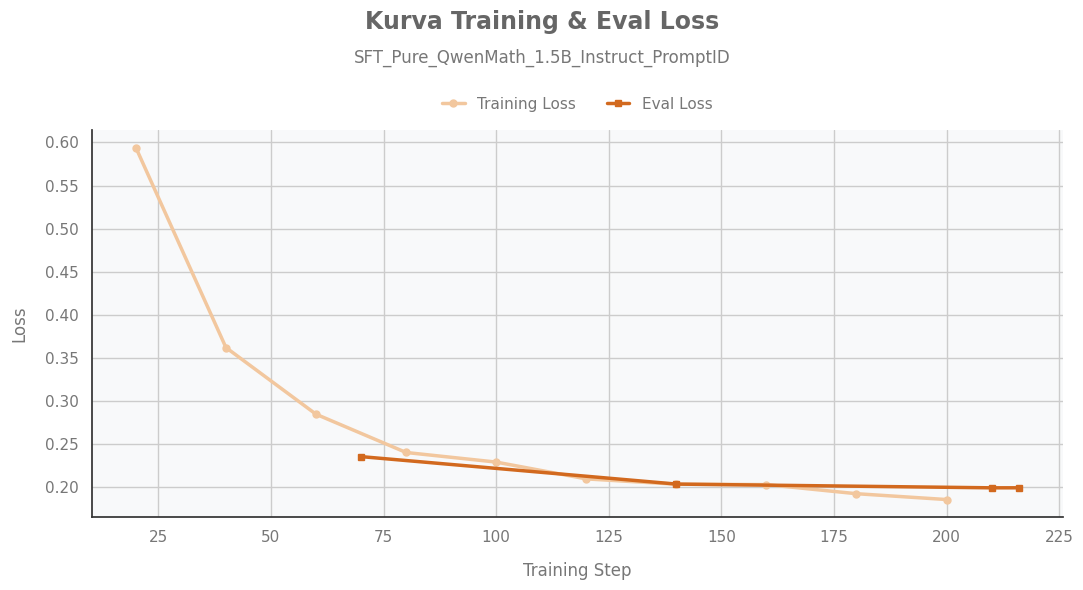

In [ ]:
plot_training_curves(result_pure_model["log_history"], result_pure_model["run_name"])

In [ ]:
plot_epoch_accuracy_progression(result_pure_model["epoch_records"], result_pure_model["run_name"])

[SFT_Pure_QwenMath_1.5B_Instruct_PromptID] Tidak ada data epoch-eval untuk diplot.


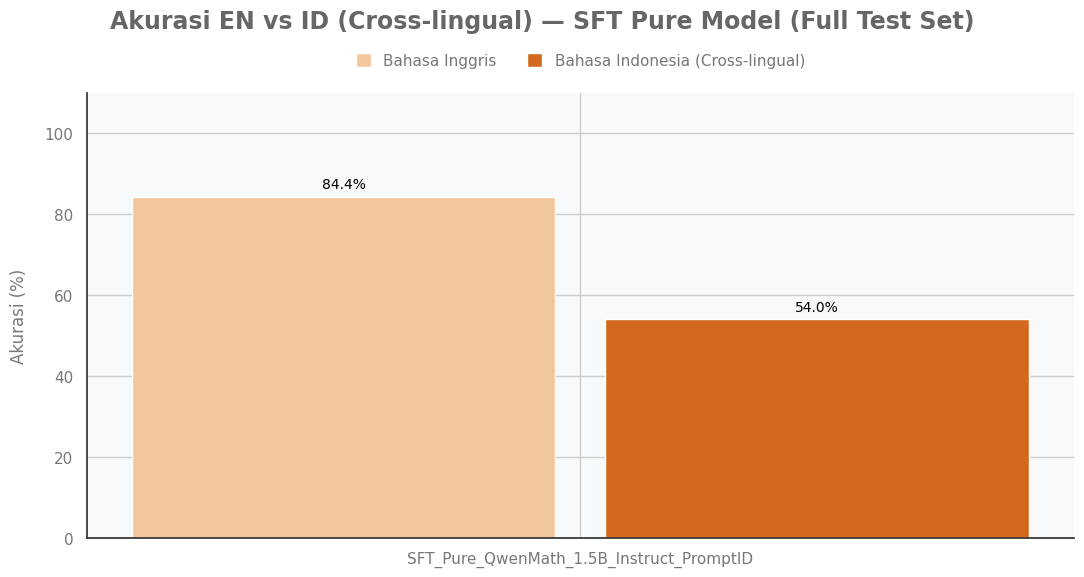

,Skenario,Bahasa,Akurasi
0,SFT_Pure_QwenMath_1.5B_Instruct_PromptID,Bahasa Inggris,84.382108
1,SFT_Pure_QwenMath_1.5B_Instruct_PromptID,Bahasa Indonesia (Cross-lingual),53.980288


In [ ]:
plot_bilingual_comparison(
    scenario_labels=[result_pure_model["run_name"]],
    acc_en_list=[result_pure_model["accuracy_en"]],
    acc_id_list=[result_pure_model["accuracy_id_cross"]],
    title="Akurasi EN vs ID (Cross-lingual) — SFT Pure Model (Full Test Set)",
    filename=f"bilingual_comparison_{result_pure_model['run_name']}.png",
    id_label="Bahasa Indonesia (Cross-lingual)",
)

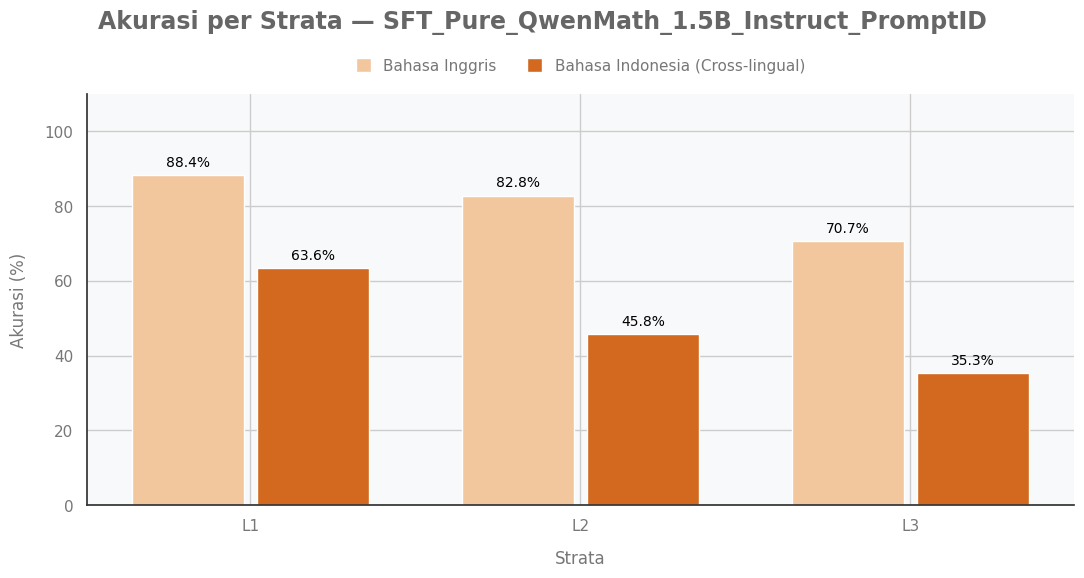

,Strata,Bahasa,Akurasi
0,L1,Bahasa Inggris,88.378766
1,L1,Bahasa Indonesia (Cross-lingual),63.558106
2,L2,Bahasa Inggris,82.838983
3,L2,Bahasa Indonesia (Cross-lingual),45.762712
4,L3,Bahasa Inggris,70.666667
5,L3,Bahasa Indonesia (Cross-lingual),35.333333


In [ ]:
plot_stratum(
    per_stratum_en=result_pure_model["per_stratum_en"],
    per_stratum_id=result_pure_model["per_stratum_id_cross"],
    title=f"Akurasi per Strata — {result_pure_model['run_name']}",
    filename=f"stratum_{result_pure_model['run_name']}.png",
    id_label="Bahasa Indonesia (Cross-lingual)",
)

## Section 12 - Eksperimen 2: SFT pada Model Hasil SLERP Merging



In [ ]:
RUN_NAME_MERGED = "SFT_SLERP_Merged_QwenMath_1.5B_PromptID"

result_merged_model = run_sft_pipeline(
    base_model_path=SLERP_MERGED_DIR,
    run_name=RUN_NAME_MERGED,
    target_cot_col="solution_distilled",
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    epoch_val_q_id=epoch_val_q_id,
    epoch_val_answers=epoch_val_answers,
    epoch_val_q_en=epoch_val_q_en if EPOCH_TRACK_EN_AVAILABLE else None,
)

final_results.append(result_merged_model)

==((====))==  Unsloth 2026.8.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Audit panjang token kolom 'solution_distilled':
  Rata-rata      : 290.6 token
  Maksimum       : 770 token
  P95            : 438.9 token
  Berisiko terpotong (>1843 token): 0 dari 3442


Map:   0%|          | 0/3442 [00:00<?, ? examples/s]

Map:   0%|          | 0/383 [00:00<?, ? examples/s]

...


Melatih model [SFT_SLERP_Merged_QwenMath_1.5B_PromptID]...
Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
{'loss': '0.5604', 'grad_norm': '0.9567', 'learning_rate': '2.591e-05', 'epoch': '0.1856'}
{'loss': '0.3467', 'grad_norm': '0.647', 'learning_rate': '2.944e-05', 'epoch': '0.3712'}
{'loss': '0.2682', 'grad_norm': '0.6323', 'learning_rate': '2.739e-05', 'epoch': '0.5568'}
{'eval_loss': '0.221', 'eval_runtime': '8.821', 'eval_samples_per_second': '43.42', 'eval_steps_per_second': '5.441', 'epoch': '0.6497'}
{'loss': '0.2231', 'grad_norm': '0.5533', 'learning_rate': '2.405e-05', 'epoch': '0.7425'}
{'loss': '0.2112', 'grad_norm': '0.6642', 'learning_rate': '1.977e-05', 'epoch': '0.9281'}
{'loss': '0.1953', 'grad_norm': '0.6238', 'learning_rate': '1.5e-05', 'epoch': '1.111'}
{'loss': '0.1887', 'grad_norm': '0.5207', 'learning_rate': '1.023e-05', 'epoch': '1.297'}
{'eval_loss': '0.19', 'eval_runtime': '

SFT_SLERP_Merged_QwenMath_1.5B_PromptID | Evaluasi Soal ID:   0%|          | 0/83 [00:00<?, ?it/s]


Model        : SFT_SLERP_Merged_QwenMath_1.5B_PromptID
Bahasa         : Bahasa Indonesia (Prompt ID)
Prompt         : SYSTEM_PROMPT_ID
Akurasi        : 61.49%
Akurasi strata :
  L1: 69.58%
  L2: 55.51%
  L3: 42.67%
Metode ekstraksi jawaban (%):
{'boxed': 98.18, 'last_number_fallback': 1.82}


SFT_SLERP_Merged_QwenMath_1.5B_PromptID | Evaluasi Soal EN:   0%|          | 0/83 [00:00<?, ?it/s]


Model        : SFT_SLERP_Merged_QwenMath_1.5B_PromptID
Bahasa         : Bahasa Inggris
Prompt         : SYSTEM_PROMPT_EN
Akurasi        : 84.46%
Akurasi strata :
  L1: 89.53%
  L2: 80.93%
  L3: 72.00%
Metode ekstraksi jawaban (%):
{'boxed': 99.01, 'last_number_fallback': 0.99}


### Visualisasi Hasil Eksperimen 2 (Merged Model)

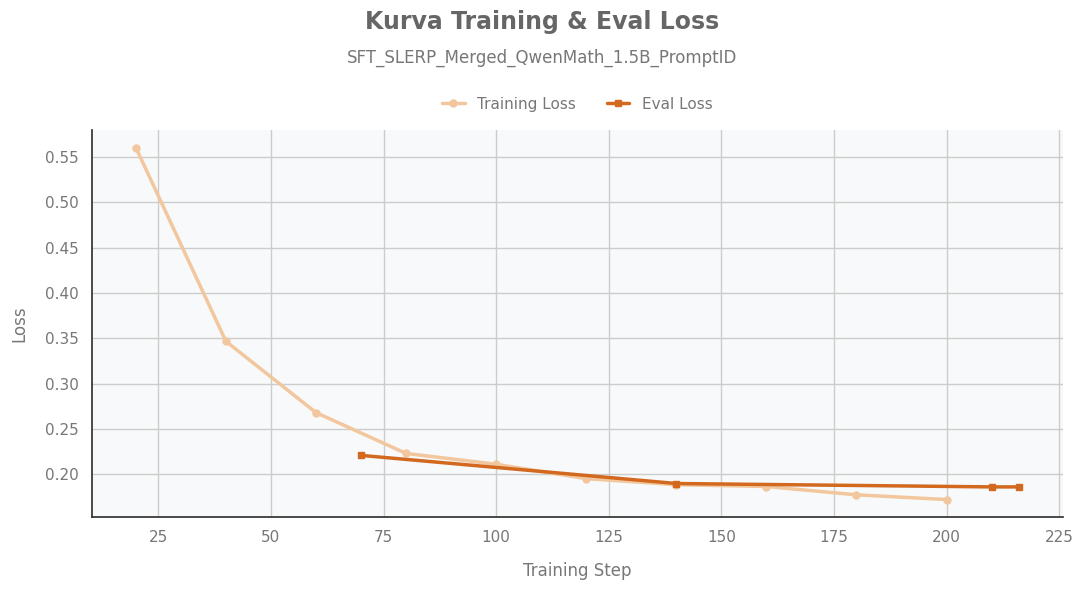

In [ ]:
plot_training_curves(result_merged_model["log_history"], result_merged_model["run_name"])

In [ ]:
plot_epoch_accuracy_progression(result_merged_model["epoch_records"], result_merged_model["run_name"])

[SFT_SLERP_Merged_QwenMath_1.5B_PromptID] Tidak ada data epoch-eval untuk diplot.


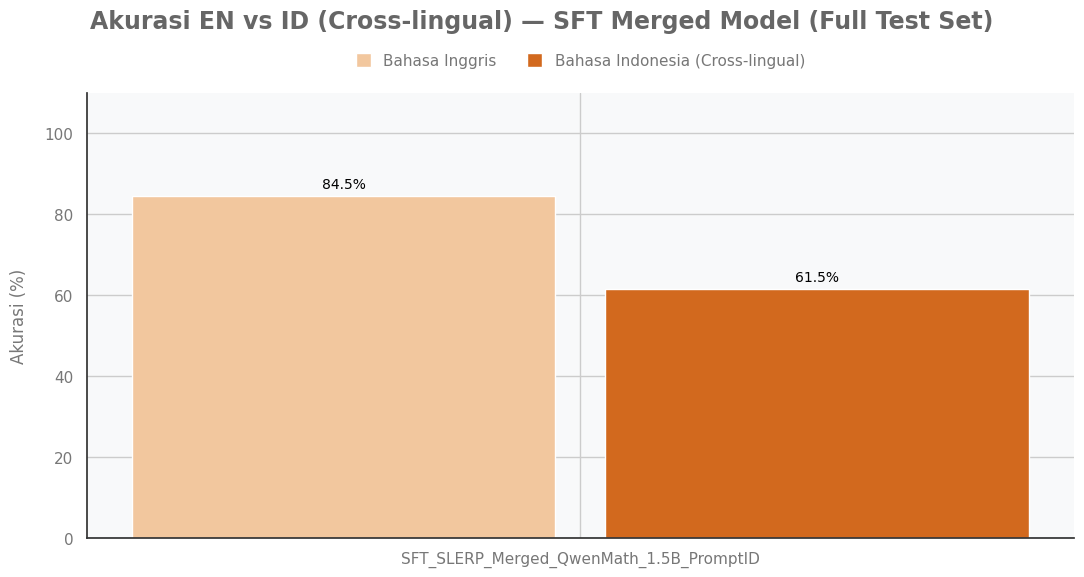

,Skenario,Bahasa,Akurasi
0,SFT_SLERP_Merged_QwenMath_1.5B_PromptID,Bahasa Inggris,84.457923
1,SFT_SLERP_Merged_QwenMath_1.5B_PromptID,Bahasa Indonesia (Cross-lingual),61.485974


In [ ]:
plot_bilingual_comparison(
    scenario_labels=[result_merged_model["run_name"]],
    acc_en_list=[result_merged_model["accuracy_en"]],
    acc_id_list=[result_merged_model["accuracy_id_cross"]],
    title="Akurasi EN vs ID (Cross-lingual) — SFT Merged Model (Full Test Set)",
    filename=f"bilingual_comparison_{result_merged_model['run_name']}.png",
    id_label="Bahasa Indonesia (Cross-lingual)",
)

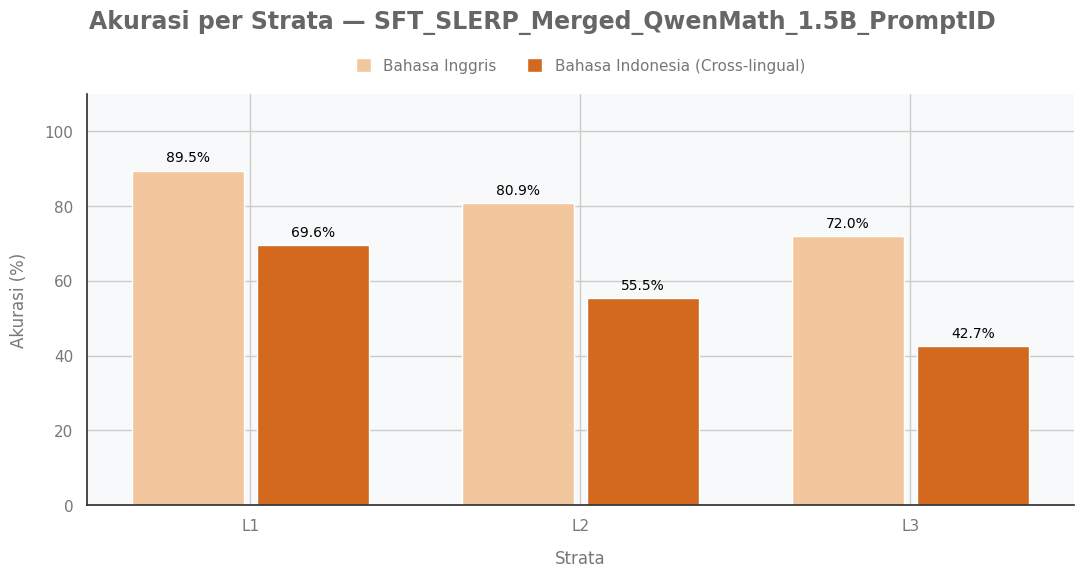

,Strata,Bahasa,Akurasi
0,L1,Bahasa Inggris,89.526542
1,L1,Bahasa Indonesia (Cross-lingual),69.583931
2,L2,Bahasa Inggris,80.932203
3,L2,Bahasa Indonesia (Cross-lingual),55.508475
4,L3,Bahasa Inggris,72.000000
5,L3,Bahasa Indonesia (Cross-lingual),42.666667


In [ ]:
plot_stratum(
    per_stratum_en=result_merged_model["per_stratum_en"],
    per_stratum_id=result_merged_model["per_stratum_id_cross"],
    title=f"Akurasi per Strata — {result_merged_model['run_name']}",
    filename=f"stratum_{result_merged_model['run_name']}.png",
    id_label="Bahasa Indonesia (Cross-lingual)",
)